In [2]:
# 로깅 설정
import logging
import asyncio
import aiohttp
import ssl
import certifi
import json
import pandas as pd
import numpy as np
import time
import random
import seaborn as sns
import sqlite3
import mysql.connector
from urllib.request import urlopen
import sys
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from DATA.stock_invest_function import *

# matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# warnings.filterwarnings("ignore")

#### 1. 상장기업 매출액 API 수신

In [3]:
# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [4]:
from datetime import datetime as _datetime_cls  # datetime 충돌 방지용
logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)

# API 키 설정
api_key = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"

# 성공/실패 추적을 위한 전역 변수들
successful_tickers = []
failed_tickers = []
total_tickers = 0
processed_count = 0
start_time = None

# 더 보수적인 설정으로 변경
max_concurrent = 10      # 동시 요청 수를 크게 줄임
base_delay = 1.0        # 기본 딜레이 증가
retry_delay = 3.0       # 재시도 딜레이 증가
max_retries = 5         # 재시도 횟수 증가
batch_size = 100        # 배치 크기

def print_progress_bar(current, total, success_count, bar_length=40):
    """실시간 진행 상황 바 출력"""
    if total == 0:
        return

    progress = current / total
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '░' * (bar_length - filled_length)

    # 시간 계산
    elapsed = time.time() - start_time if start_time else 0
    elapsed_str = f"{int(elapsed//60)}:{int(elapsed%60):02d}"

    if current > 0:
        avg_time_per_ticker = elapsed / current
        remaining_time = avg_time_per_ticker * (total - current)
        remaining_str = f"{int(remaining_time//60)}:{int(remaining_time%60):02d}"
    else:
        remaining_str = "계산중..."

    success_rate = (success_count / current * 100) if current > 0 else 0
    failed_count = current - success_count

    print(f"\r🔄 진행: [{bar}] {current}/{total} ({progress*100:.1f}%)")
    print(f"✅ 성공: {success_count} | ❌ 실패: {failed_count} | 📈 성공률: {success_rate:.1f}%")
    print(f"⏱️  경과: {elapsed_str} | 예상잔여: {remaining_str}")
    print("-" * 70)

def get_jsonparsed_data(url, timeout=15):
    """동기 방식으로 JSON 데이터 가져오기 (재시도 로직 포함)"""
    for attempt in range(3):
        try:
            context = ssl.create_default_context(cafile=certifi.where())
            with urlopen(url, context=context, timeout=timeout) as response:
                data = response.read().decode("utf-8")
                return json.loads(data)
        except Exception as e:
            print(f"⚠️  API 요청 실패 (시도 {attempt + 1}/3): {str(e)[:50]}...")
            if attempt < 2:
                time.sleep(2)
    return None

async def fetch_json_data_safe(url, session, semaphore, ticker, retry_count=None):
    """안전한 비동기 JSON 데이터 수집"""
    if retry_count is None:
        retry_count = max_retries

    async with semaphore:
        for attempt in range(retry_count):
            try:
                # 요청 간격을 랜덤하게 조절
                delay = base_delay + random.uniform(0.5, 2.0)
                if attempt > 0:  # 재시도인 경우 더 긴 대기
                    delay = retry_delay + random.uniform(1.0, 4.0)

                await asyncio.sleep(delay)

                print(f"📡 {ticker} 요청 중... (시도 {attempt + 1}/{retry_count})")

                async with session.get(url, timeout=20) as response:
                    if response.status == 200:
                        text_data = await response.text()
                        if text_data.strip():  # 빈 응답 체크
                            data = json.loads(text_data)
                            if data:  # 빈 데이터 체크
                                print(f"✅ {ticker} 성공!")
                                return data
                            else:
                                print(f"⚠️  {ticker} 빈 데이터 응답")
                        else:
                            print(f"⚠️  {ticker} 빈 응답")

                    elif response.status == 429:
                        # Rate limit 처리
                        wait_time = (2 ** attempt) + random.uniform(1, 5)
                        print(f"⏳ {ticker} Rate limit - {wait_time:.1f}초 대기...")
                        await asyncio.sleep(wait_time)

                    elif response.status == 403:
                        print(f"🚫 {ticker} API 권한 오류 (403)")
                        break  # 403은 재시도해도 의미없음

                    else:
                        print(f"❌ {ticker} HTTP {response.status}")

            except asyncio.TimeoutError:
                print(f"⏱️  {ticker} 타임아웃 (시도 {attempt + 1})")

            except json.JSONDecodeError:
                print(f"🔧 {ticker} JSON 파싱 오류 (시도 {attempt + 1})")

            except Exception as e:
                print(f"💥 {ticker} 오류: {str(e)[:30]}... (시도 {attempt + 1})")

            # 마지막 시도가 아니면 잠시 대기
            if attempt < retry_count - 1:
                extra_wait = random.uniform(2, 5)
                print(f"⏳ {ticker} {extra_wait:.1f}초 후 재시도...")
                await asyncio.sleep(extra_wait)

    print(f"💔 {ticker} 최종 실패")
    return None

async def fetch_stock_profile_safe(ticker, session, semaphore):
    """안전한 개별 주식 프로필 수집"""
    url = f"https://financialmodelingprep.com/api/v3/profile/{ticker}?apikey={api_key}"

    try:
        data = await fetch_json_data_safe(url, session, semaphore, ticker)

        if data and len(data) > 0:
            df = pd.DataFrame(data)
            successful_tickers.append(ticker)
            return df
        else:
            failed_tickers.append(ticker)
            return None

    except Exception as e:
        print(f"💥 {ticker} 예외 발생: {e}")
        failed_tickers.append(ticker)
        return None

async def download_profiles_batch(ticker_batch, batch_num, total_batches):
    """배치 단위로 프로필 다운로드"""
    print(f"\n🎯 배치 {batch_num}/{total_batches} 시작 ({len(ticker_batch)}개 종목)")
    print("=" * 60)

    # SSL 및 연결 설정 (더 보수적으로)
    ssl_context = ssl.create_default_context(cafile=certifi.where())
    connector = aiohttp.TCPConnector(
        ssl=ssl_context,
        limit=50,        # 연결 풀 크기 감소
        limit_per_host=20,  # 호스트당 연결 수 감소
        ttl_dns_cache=300,  # DNS 캐시 시간
        use_dns_cache=True
    )

    # 타임아웃 설정 증가
    timeout = aiohttp.ClientTimeout(
        total=60,      # 전체 타임아웃
        connect=15,    # 연결 타임아웃
        sock_read=20   # 소켓 읽기 타임아웃
    )

    semaphore = asyncio.Semaphore(max_concurrent)

    async with aiohttp.ClientSession(
        connector=connector,
        timeout=timeout,
        headers={'User-Agent': 'Mozilla/5.0 (compatible; DataCollector/1.0)'}
    ) as session:

        tasks = [
            fetch_stock_profile_safe(ticker, session, semaphore)
            for ticker in ticker_batch
        ]

        results = []
        completed = 0
        batch_start_success = len(successful_tickers)

        # 진행 상황을 실시간으로 모니터링
        for coro in asyncio.as_completed(tasks):
            try:
                result = await coro
                if result is not None:
                    results.append(result)

                completed += 1

                # 진행 상황 업데이트 (5개마다 또는 완료시)
                if completed % 5 == 0 or completed == len(tasks):
                    # 이전 출력 지우기
                    for _ in range(4):
                        print("\033[F\033[K", end="")

                    current_batch_success = len(successful_tickers) - batch_start_success
                    print_progress_bar(completed, len(tasks), current_batch_success)

            except Exception as e:
                completed += 1
                print(f"💥 태스크 실행 오류: {e}")

    batch_success = len(successful_tickers) - batch_start_success
    batch_failed = len(ticker_batch) - batch_success

    print(f"\n🏁 배치 {batch_num} 완료!")
    print(f"✅ 성공: {batch_success}개 | ❌ 실패: {batch_failed}개")
    print(f"📈 배치 성공률: {batch_success/len(ticker_batch)*100:.1f}%")

    return results

async def retry_failed_tickers(max_retry_attempts=2):
    """실패한 티커들 재시도"""
    global failed_tickers

    if not failed_tickers:
        print("🎉 재시도할 실패 티커가 없습니다!")
        return []

    print(f"\n🔄 실패한 {len(failed_tickers)}개 티커 재시도 시작...")

    # 재시도를 위해 실패 목록 복사
    retry_list = failed_tickers.copy()
    failed_tickers.clear()  # 실패 목록 초기화

    all_retry_results = []

    # 더 작은 배치로 재시도
    retry_batch_size = 50
    for attempt in range(max_retry_attempts):
        if not retry_list:
            break

        print(f"\n🔄 재시도 {attempt + 1}/{max_retry_attempts} 시작...")
        print(f"📊 재시도 대상: {len(retry_list)}개")

        current_retry_results = []

        # 작은 배치로 나누어 재시도
        for i in range(0, len(retry_list), retry_batch_size):
            batch = retry_list[i:i + retry_batch_size]
            batch_num = i // retry_batch_size + 1
            total_batches = (len(retry_list) + retry_batch_size - 1) // retry_batch_size

            print(f"\n🎯 재시도 배치 {batch_num}/{total_batches}")

            batch_results = await download_profiles_batch(
                batch, batch_num, total_batches
            )
            current_retry_results.extend(batch_results)

            # 배치 간 더 긴 휴식
            if i + retry_batch_size < len(retry_list):
                print("⏳ 재시도 배치 간 10초 휴식...")
                await asyncio.sleep(10)

        all_retry_results.extend(current_retry_results)

        # 다음 재시도를 위해 여전히 실패한 것들만 남김
        retry_list = failed_tickers.copy()
        failed_tickers.clear()

        if retry_list:
            print(f"⚠️  {len(retry_list)}개 종목이 여전히 실패상태")
            if attempt < max_retry_attempts - 1:
                print("⏳ 다음 재시도까지 15초 대기...")
                await asyncio.sleep(15)
        else:
            print("🎉 모든 재시도 성공!")
            break

    # 최종적으로 실패한 것들을 다시 실패 목록에 추가
    if retry_list:
        failed_tickers.extend(retry_list)

    return all_retry_results

# 이벤트 루프 감지 및 처리 함수
def get_or_create_eventloop():
    """현재 이벤트 루프가 실행 중인지 확인하고 적절하게 처리"""
    try:
        # 현재 실행 중인 이벤트 루프가 있는지 확인
        loop = asyncio.get_running_loop()
        return loop, True  # 실행 중인 루프가 있음
    except RuntimeError:
        # 실행 중인 루프가 없음
        return None, False

async def run_batch_processing():
    """전체 배치 처리를 담당하는 코루틴"""
    global all_results, total_batches

    all_results = []
    total_batches = (len(ticker_list) + batch_size - 1) // batch_size

    try:
        for i in range(0, len(ticker_list), batch_size):
            batch = ticker_list[i:i + batch_size]
            batch_num = i // batch_size + 1

            try:
                batch_results = await download_profiles_batch(batch, batch_num, total_batches)
                all_results.extend(batch_results)

            except Exception as e:
                print(f"💥 배치 {batch_num} 처리 중 오류: {e}")
                # 배치 전체가 실패한 경우 해당 티커들을 실패 목록에 추가
                failed_tickers.extend(batch)

            # 배치 간 휴식 (마지막 배치가 아닌 경우)
            if i + batch_size < len(ticker_list):
                print("\n⏳ 배치 간 5초 휴식...")
                await asyncio.sleep(5)

        print(f"\n🏁 1차 수집 완료!")
        print(f"✅ 성공: {len(successful_tickers)}개")
        print(f"❌ 실패: {len(failed_tickers)}개")

        # 실패한 티커들 재시도
        if failed_tickers:
            print(f"\n🔄 실패 티커들 재시도 시작...")
            retry_results = await retry_failed_tickers()
            all_results.extend(retry_results)

    except KeyboardInterrupt:
        print("\n⏹️  사용자에 의해 중단되었습니다.")
    except Exception as e:
        print(f"\n💥 예상치 못한 오류 발생: {e}")

# =================================================================
# 메인 실행 코드 시작
# =================================================================

print("🚀 " + "="*60)
print("📈 개선된 FMP API 주식 데이터 수집기 시작!")
print(f"⚙️  동시 요청 수: {max_concurrent}")
print(f"⏱️  기본 딜레이: {base_delay}초")
print(f"🔄 최대 재시도: {max_retries}회")
print(f"📦 배치 크기: {batch_size}")
print("="*60)

# 시작 시간 기록
start_time = time.time()

print("📋 주식 리스트 가져오는 중...")

# # 1. 주식 리스트 가져오기
# url = f"https://financialmodelingprep.com/api/v3/stock/list?apikey={api_key}"
# stock_list = get_jsonparsed_data(url)
#
# if not stock_list:
#     print("❌ 주식 리스트를 가져올 수 없습니다.")
#     exit()
#
# print("✅ 주식 리스트 수신 완료!")
#
# # DataFrame 변환 및 필터링
# stock_listed = pd.DataFrame(stock_list)

try:
    from DATA.us_target_ticker_list_2000 import ticker_list as ticker_list
except ImportError as e:
    print(f"[ERROR] us_target_ticker_list_2000.py import 실패: {e}")
    print("  DATA 폴더 안에 us_target_ticker_list_2000.py 가 있는지 확인하세요.")
    sys.exit(1)

print("📊 데이터 필터링 중...")

# # 조건 설정
# con1 = stock_listed['exchangeShortName'] == 'NASDAQ'
# con2 = stock_listed['exchangeShortName'] == 'NYSE'
# con3 = stock_listed['exchangeShortName'] == 'AMEX'
# con4 = stock_listed['type'] == 'stock'
#
# # 필터링
# stock_screen1 = stock_listed[con1 | con2 | con3].copy()
# con4_aligned = con4.reindex(stock_screen1.index)
# stock_screen2 = stock_screen1[con4_aligned].copy()
#
# us_stock_info = stock_screen2
# ticker_list = us_stock_info['symbol'].unique().tolist()
#
# print(f"📊 필터링 완료! 처리 대상 티커: {len(ticker_list)}개")

# 대용량 데이터 경고 및 테스트 모드 옵션
if len(ticker_list) > 1000:
    print(f"\n⚠️  대용량 데이터입니다. 전체 처리 시 수 시간이 소요될 수 있습니다.")
    print("📝 테스트용으로 처음 500개만 처리하려면 't'를 입력하세요.")
    print("📝 전체 처리하려면 Enter 또는 다른 키를 누르세요.")

    try:
        response = input("처리 방식 선택 (t: 테스트 500개 | Enter: 전체 처리): ")

        if response.lower() == 't':
            ticker_list = ticker_list[:500]
            print(f"🎯 테스트 모드: {len(ticker_list)}개 티커만 처리합니다.")
        else:
            print(f"🎯 전체 모드: {len(ticker_list)}개 티커를 모두 처리합니다.")
    except:
        print(f"🎯 입력 없음. 전체 {len(ticker_list)}개 티커를 처리합니다.")

total_tickers = len(ticker_list)

print(f"\n🚀 데이터 수집 시작!")
print(f"📊 총 {total_tickers}개 종목 처리 예정")

# 2. 이벤트 루프 상태에 따른 실행 방식 결정
loop, is_running = get_or_create_eventloop()

if is_running:
    # 이미 실행 중인 이벤트 루프가 있는 경우 (Jupyter 등)
    print("🔄 기존 이벤트 루프에서 실행 중...")
    import nest_asyncio
    nest_asyncio.apply()

    # 태스크로 실행
    task = asyncio.create_task(run_batch_processing())
    await task
else:
    # 새로운 이벤트 루프 생성해서 실행
    print("🔄 새 이벤트 루프 생성해서 실행...")
    asyncio.run(run_batch_processing())

# 4. 결과 합치기
if all_results:
    info = pd.concat([df for df in all_results if df is not None], ignore_index=True)
    print(f"✅ 최종 수집된 데이터: {len(info)}개 프로필")
else:
    info = pd.DataFrame()
    print("❌ 수집된 데이터가 없습니다.")

# 5. 최종 리포트
total_time = time.time() - start_time if start_time else 0

print("\n" + "🏁" * 60)
print("🎊 데이터 수집 최종 완료!")
print("🏁" * 60)

print(f"📊 총 처리 대상: {total_tickers}개")
print(f"✅ 성공: {len(successful_tickers)}개")
print(f"❌ 최종 실패: {len(failed_tickers)}개")
print(f"📈 최종 성공률: {len(successful_tickers)/total_tickers*100:.1f}%")
print(f"⏱️  총 소요시간: {int(total_time//3600)}시간 {int((total_time%3600)//60)}분 {int(total_time%60)}초")
print(f"⚡ 평균 처리시간: {total_time/total_tickers:.2f}초/종목")

# 6. 중요 종목들 상태 체크
important_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'TEL']
print(f"\n🎯 주요 종목 수집 상태:")
for ticker in important_tickers:
    if ticker in successful_tickers:
        print(f"✅ {ticker}: 성공")
    elif ticker in failed_tickers:
        print(f"❌ {ticker}: 실패")
    elif ticker in ticker_list:
        print(f"❓ {ticker}: 처리 대상이었으나 결과 없음")
    else:
        print(f"➖ {ticker}: 처리 대상 아님")

# 7. 실패 티커 처리
if failed_tickers:
    print(f"\n💔 실패 티커 샘플 (처음 20개):")
    print(failed_tickers[:20])

    # 실패 티커를 파일로 저장
    failed_df = pd.DataFrame({
        'failed_ticker': failed_tickers,
        'timestamp': [_datetime_cls.now().strftime('%Y-%m-%d %H:%M:%S')] * len(failed_tickers)
    })
    failed_filename = f"failed_tickers_{_datetime_cls.now().strftime('%Y%m%d_%H%M%S')}.csv"
    failed_df.to_csv(failed_filename, index=False)
    print(f"💾 실패 티커들이 {failed_filename}에 저장되었습니다.")

# 8. 성공 티커를 파일로 저장
if successful_tickers:
    successful_df = pd.DataFrame({
        'successful_ticker': successful_tickers,
        'timestamp': [_datetime_cls.now().strftime('%Y-%m-%d %H:%M:%S')] * len(successful_tickers)
    })
    success_filename = f"successful_tickers_{_datetime_cls.now().strftime('%Y%m%d_%H%M%S')}.csv"
    successful_df.to_csv(success_filename, index=False)
    print(f"💾 성공 티커들이 {success_filename}에 저장되었습니다.")

print("🏁" * 60)

# 9. 수집 결과 미리보기
if not info.empty:
    print(f"\n📈 수집 결과 미리보기:")
    print(info.head())
    print(f"\n📊 데이터 형태: {info.shape}")
    print(f"📋 컬럼: {info.columns.tolist()}")

    if 'symbol' in info.columns:
        print(f"📋 수집된 종목 예시: {info['symbol'].head(10).tolist()}")

        # 최종 DataFrame에서 중요 티커들 확인
        print(f"\n🔍 최종 DataFrame에서 주요 종목 확인:")
        for ticker in important_tickers:
            ticker_data = info[info['symbol'] == ticker]
            if not ticker_data.empty:
                print(f"✅ {ticker}: DataFrame에 포함됨 ({len(ticker_data)} records)")
            else:
                print(f"❌ {ticker}: DataFrame에 없음")
else:
    print(f"\n❌ 수집된 데이터가 없습니다.")

# 10. 사용 가능한 변수들 안내
print(f"\n🔧 사용 가능한 변수들:")
print(f"• info: 수집된 최종 데이터프레임 ({len(info) if not info.empty else 0} rows)")
print(f"• successful_tickers: 성공한 티커 리스트 ({len(successful_tickers)}개)")
print(f"• failed_tickers: 실패한 티커 리스트 ({len(failed_tickers)}개)")
print(f"• ticker_list: 원본 처리 대상 티커 리스트 ({len(ticker_list)}개)")

print(f"\n📝 사용 예시:")
print(f"• 특정 티커 성공 여부: print('TSLA' in successful_tickers)")
print(f"• 실패 티커 확인: print(failed_tickers[:10])")
print(f"• DataFrame 정보: print(info.info())")

print(f"\n🎊 수집 작업이 완료되었습니다!")

🚀 ============================================================
📈 개선된 FMP API 주식 데이터 수집기 시작!
⚙️  동시 요청 수: 10
⏱️  기본 딜레이: 1.0초
🔄 최대 재시도: 5회
📦 배치 크기: 100
📋 주식 리스트 가져오는 중...
📊 데이터 필터링 중...

⚠️  대용량 데이터입니다. 전체 처리 시 수 시간이 소요될 수 있습니다.
📝 테스트용으로 처음 500개만 처리하려면 't'를 입력하세요.
📝 전체 처리하려면 Enter 또는 다른 키를 누르세요.
🎯 전체 모드: 2000개 티커를 모두 처리합니다.

🚀 데이터 수집 시작!
📊 총 2000개 종목 처리 예정
🔄 기존 이벤트 루프에서 실행 중...

🎯 배치 1/20 시작 (100개 종목)
📡 PEP 요청 중... (시도 1/5)
📡 ISRG 요청 중... (시도 1/5)
📡 AMGN 요청 중... (시도 1/5)
📡 INTC 요청 중... (시도 1/5)
📡 DIS 요청 중... (시도 1/5)
✅ PEP 성공!
📡 APH 요청 중... (시도 1/5)
✅ ISRG 성공!
📡 KLAC 요청 중... (시도 1/5)
📡 TMUS 요청 중... (시도 1/5)
✅ APH 성공!
📡 ABT 요청 중... (시도 1/5)
✅ KLAC 성공!
✅ AMGN 성공!
🔄 진행: [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 5/100 (5.0%)
✅ 성공: 5 | ❌ 실패: 0 | 📈 성공률: 100.0%
⏱️  경과: 0:16 | 예상잔여: 5:19
----------------------------------------------------------------------
✅ ABT 성공!
✅ INTC 성공!
📡 BA 요청 중... (시도 1/5)
✅ DIS 성공!
✅ BA 성공!
✅ TMUS 성공!
🔄 진행: [████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 10/100 (10.0%)
✅

In [22]:
# info[info['symbol'] == 'AAPL']

In [5]:
from datetime import datetime, date
from dateutil.relativedelta import relativedelta

# 로깅 설정 (ERROR만 표시)
logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)


# API 키 설정
api_key = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"

# 날짜 관련 함수들
def get_last_quarter_end():
    """마지막 분기 마지막 날을 반환하는 함수"""
    today = date.today()
    quarter_months = [3, 6, 9, 12]

    # 현재 월에서 가장 가까운 이전 분기 마지막 월 찾기
    current_month = today.month
    last_quarter_month = None

    for month in reversed(quarter_months):
        if month < current_month:
            last_quarter_month = month
            break

    # 만약 현재가 1-3월이라면 작년 12월
    if last_quarter_month is None:
        last_quarter_month = 12
        year = today.year - 1
    else:
        year = today.year

    # 해당 월의 마지막 날 구하기
    import calendar
    last_day = calendar.monthrange(year, last_quarter_month)[1]

    return date(year, last_quarter_month, last_day)

def get_last_month_end():
    """지난 달 마지막 날을 반환하는 함수"""
    today = date.today()
    # 이번 달 첫째 날에서 하루 빼기 = 지난 달 마지막 날
    first_day_this_month = today.replace(day=1)
    last_month_end = first_day_this_month - relativedelta(days=1)
    return last_month_end

# 초기 세팅
today_date = datetime.now().strftime("%Y-%m-%d")
last_quarter_end = get_last_quarter_end()
quarter_date = last_quarter_end.strftime("%Y-%m-%d")
last_month_date = get_last_month_end()

# info 데이터 필터링 (info 변수가 정의되어 있다고 가정)
try:
    info_df = info[['symbol', 'sector', 'industry']]

    con1 = info_df['sector'] != 'Financial Services'
    con2 = info_df['sector'] != 'Real Estate'
    con3 = info_df['sector'] != 'Utilities'
    con4 = info_df['sector'] != ''

    info_re = info_df[con1 & con2 & con3 & con4].copy()
    tic_list = info_re['symbol'].unique().tolist()

    print(f"Total tickers to process: {len(tic_list)}")
except NameError:
    print("Error: 'info' variable not found. Please ensure it's defined before running this code.")
    tic_list = []

# 컬럼 매핑
compustat_is = ['report_date', 'ticker', 'period', 'sale', 'cogs', 'gp', 'xrd', 'xsga', 'idit',
                'xint', 'dp', 'ebitda', 'xopr', 'opiti', 'opir', 'pi', 'pir', 'txt', 'ni',
                'nir', 'eps', 'epsdi', 'shrout', 'shroutdi']

# 날짜 범위 생성
dates_list = pd.date_range('2004-01-31', last_month_date, freq='M')
date_df = pd.DataFrame(dates_list, columns=['date'])

# 개선된 비동기 설정
max_concurrent = 15  # 동시 요청 수 감소
delay = 0.15  # 요청 간 딜레이 증가
max_retries = 5  # 재시도 횟수 증가
backoff_factor = 2  # 지수 백오프 팩터

# 동기 함수 (fallback용) - 개선된 버전
def get_jsonparsed_data_sync(url, max_retries=3):
    """동기식 데이터 가져오기 함수 (fallback용)"""
    for attempt in range(max_retries):
        try:
            context = ssl.create_default_context(cafile=certifi.where())
            with urlopen(url, context=context, timeout=30) as response:
                data = response.read().decode("utf-8")
                return json.loads(data)
        except Exception as e:
            if attempt == max_retries - 1:
                logger.error(f"Sync fallback failed for URL: {url}, Error: {e}")
                return None
            time.sleep(2 ** attempt)  # 지수 백오프
    return None

# 개선된 비동기 함수들
async def fetch_json_data_improved(url, session, semaphore, max_retries=5):
    """개선된 비동기 JSON 데이터 가져오기 함수"""
    async with semaphore:
        for attempt in range(max_retries):
            try:
                # 요청 간 딜레이
                await asyncio.sleep(delay)

                # 타임아웃 설정을 더 길게
                timeout = aiohttp.ClientTimeout(total=45, connect=15, sock_read=30)

                async with session.get(url, timeout=timeout) as response:
                    if response.status == 200:
                        try:
                            data = await response.text()
                            return json.loads(data)
                        except json.JSONDecodeError as e:
                            logger.warning(f"JSON decode error for {url}: {e}")
                            return None
                    elif response.status == 429:
                        # Rate limit - 더 긴 대기
                        wait_time = (backoff_factor ** attempt) * 2
                        logger.warning(f"Rate limited, waiting {wait_time}s (attempt {attempt + 1})")
                        await asyncio.sleep(wait_time)
                        continue
                    elif response.status == 403:
                        # API 키 문제 또는 권한 문제
                        logger.error(f"Access forbidden for {url}")
                        return None
                    elif response.status == 404:
                        # 데이터 없음
                        logger.info(f"No data found for {url}")
                        return None
                    else:
                        logger.warning(f"HTTP {response.status} for {url}")
                        if attempt < max_retries - 1:
                            await asyncio.sleep(backoff_factor ** attempt)
                            continue
                        return None

            except asyncio.TimeoutError:
                logger.warning(f"Timeout for {url} (attempt {attempt + 1})")
                if attempt < max_retries - 1:
                    await asyncio.sleep(backoff_factor ** attempt)
                    continue
                return None

            except aiohttp.ClientError as e:
                logger.warning(f"Client error for {url}: {e} (attempt {attempt + 1})")
                if attempt < max_retries - 1:
                    await asyncio.sleep(backoff_factor ** attempt)
                    continue
                return None

            except Exception as e:
                logger.error(f"Unexpected error for {url}: {e} (attempt {attempt + 1})")
                if attempt < max_retries - 1:
                    await asyncio.sleep(backoff_factor ** attempt)
                    continue
                return None

        return None

async def fetch_income_statement_improved(ticker, session, semaphore):
    """개선된 개별 티커 손익계산서 가져오기 함수"""
    url = f"https://financialmodelingprep.com/api/v3/income-statement/{ticker}?period=quarter&apikey={api_key}"

    try:
        # API 호출
        fs_raw = await fetch_json_data_improved(url, session, semaphore)

        if not fs_raw:
            return None, ticker

        # 데이터 검증
        if not isinstance(fs_raw, list) or len(fs_raw) == 0:
            logger.warning(f"Invalid or empty data structure for {ticker}")
            return None, ticker

        temp_df = pd.DataFrame(fs_raw)

        if temp_df.empty:
            logger.warning(f"Empty DataFrame for {ticker}")
            return None, ticker

        # 필수 컬럼 확인
        required_basic_columns = ['date', 'symbol', 'period']
        missing_basic = [col for col in required_basic_columns if col not in temp_df.columns]

        if missing_basic:
            logger.warning(f"Missing basic columns for {ticker}: {missing_basic}")
            return None, ticker

        # 사용 가능한 컬럼만 선택
        all_possible_columns = ['date', 'symbol', 'period', 'revenue', 'costOfRevenue', 'grossProfit',
                               'researchAndDevelopmentExpenses', 'sellingGeneralAndAdministrativeExpenses',
                               'interestIncome', 'interestExpense', 'depreciationAndAmortization', 'ebitda',
                               'operatingExpenses', 'operatingIncome', 'operatingIncomeRatio', 'incomeBeforeTax',
                               'incomeBeforeTaxRatio', 'incomeTaxExpense', 'netIncome', 'netIncomeRatio',
                               'eps', 'epsdiluted', 'weightedAverageShsOut', 'weightedAverageShsOutDil']

        available_columns = [col for col in all_possible_columns if col in temp_df.columns]

        if len(available_columns) < 5:  # 최소한의 데이터가 있는지 확인
            logger.warning(f"Insufficient data columns for {ticker}: {len(available_columns)}")
            return None, ticker

        is_df = temp_df[available_columns].copy()

        # 안전한 컬럼명 매핑
        num_cols_to_map = min(len(available_columns), len(compustat_is))
        column_mapping = dict(zip(available_columns[:num_cols_to_map], compustat_is[:num_cols_to_map]))
        is_df = is_df.rename(columns=column_mapping)

        # 날짜 처리 - 더 안전하게
        try:
            is_df['report_date'] = pd.to_datetime(is_df['report_date'], errors='coerce')

            # 유효하지 않은 날짜 제거
            valid_dates = is_df['report_date'].notna()
            if not valid_dates.any():
                logger.warning(f"No valid dates for {ticker}")
                return None, ticker

            is_df = is_df[valid_dates].copy()
            is_df_sorted = is_df.sort_values(by='report_date')

            # 날짜 변환
            is_df_sorted['date_month'] = is_df_sorted['report_date'].dt.to_period('M').astype(str)
            is_df_sorted['date'] = pd.to_datetime(is_df_sorted['date_month']) + pd.offsets.MonthEnd(0)

            # 날짜 범위와 병합
            temp_is = pd.merge(date_df, is_df_sorted, on=['date'], how='left')

            # forward fill 적용
            temp_is = temp_is.ffill()

            return temp_is, None

        except Exception as date_error:
            logger.error(f"Date processing error for {ticker}: {date_error}")
            return None, ticker

    except Exception as e:
        logger.error(f"Processing error for {ticker}: {e}")
        return None, ticker

async def download_all_income_statements_improved(ticker_list):
    """개선된 모든 티커 손익계산서 비동기 다운로드"""
    # SSL 설정 개선
    ssl_context = ssl.create_default_context(cafile=certifi.where())
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    # 커넥터 설정 개선
    connector = aiohttp.TCPConnector(
        ssl=ssl_context,
        limit=40,  # 전체 연결 제한
        limit_per_host=20,  # 호스트당 연결 제한
        keepalive_timeout=60,
        enable_cleanup_closed=True,
        force_close=True,  # 연결 강제 종료로 리소스 정리
        ttl_dns_cache=300  # DNS 캐시 TTL
    )

    # 타임아웃 설정 개선
    timeout = aiohttp.ClientTimeout(
        total=60,  # 전체 타임아웃 증가
        connect=20,  # 연결 타임아웃
        sock_read=40  # 읽기 타임아웃
    )

    semaphore = asyncio.Semaphore(max_concurrent)

    # 사용자 정의 헤더 추가
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept': 'application/json',
        'Accept-Encoding': 'gzip, deflate',
        'Connection': 'keep-alive'
    }

    async with aiohttp.ClientSession(
        connector=connector,
        timeout=timeout,
        headers=headers,
        trust_env=True
    ) as session:

        tasks = [fetch_income_statement_improved(ticker, session, semaphore) for ticker in ticker_list]

        results = []
        error_list = []
        completed = 0
        successful = 0
        total = len(tasks)

        print(f"Starting download of {total} income statements...")

        # 더 세밀한 진행률 추적
        for coro in asyncio.as_completed(tasks):
            try:
                result, failed_ticker = await coro

                if result is not None:
                    results.append(result)
                    successful += 1
                    logger.info(f"Successfully processed ticker: {result['ticker'].iloc[0] if 'ticker' in result.columns and not result.empty else 'unknown'}")
                elif failed_ticker:
                    error_list.append(failed_ticker)
                    logger.warning(f"Failed to process ticker: {failed_ticker}")

                completed += 1

                # 25개마다 진행률 출력
                if completed % 25 == 0 or completed == total:
                    success_rate = (successful / completed * 100) if completed > 0 else 0
                    print(f"Progress: {completed}/{total} ({completed/total*100:.1f}%) - Success: {successful} ({success_rate:.1f}%) - Errors: {len(error_list)}")

            except Exception as e:
                completed += 1
                error_list.append("processing_error")
                logger.error(f"Task processing error: {e}")

    return results, error_list

# 동기식 fallback 함수 개선
def process_ticker_sync(ticker):
    """동기식 티커 처리 (fallback)"""
    url = f"https://financialmodelingprep.com/api/v3/income-statement/{ticker}?period=quarter&apikey={api_key}"

    try:
        fs_raw = get_jsonparsed_data_sync(url)

        if not fs_raw or not isinstance(fs_raw, list) or len(fs_raw) == 0:
            return None, ticker

        temp_df = pd.DataFrame(fs_raw)

        if temp_df.empty:
            return None, ticker

        # 기본 처리 로직 (비동기 버전과 동일)
        all_possible_columns = ['date', 'symbol', 'period', 'revenue', 'costOfRevenue', 'grossProfit',
                               'researchAndDevelopmentExpenses', 'sellingGeneralAndAdministrativeExpenses',
                               'interestIncome', 'interestExpense', 'depreciationAndAmortization', 'ebitda',
                               'operatingExpenses', 'operatingIncome', 'operatingIncomeRatio', 'incomeBeforeTax',
                               'incomeBeforeTaxRatio', 'incomeTaxExpense', 'netIncome', 'netIncomeRatio',
                               'eps', 'epsdiluted', 'weightedAverageShsOut', 'weightedAverageShsOutDil']

        available_columns = [col for col in all_possible_columns if col in temp_df.columns]

        if len(available_columns) < 5:
            return None, ticker

        is_df = temp_df[available_columns].copy()

        num_cols_to_map = min(len(available_columns), len(compustat_is))
        column_mapping = dict(zip(available_columns[:num_cols_to_map], compustat_is[:num_cols_to_map]))
        is_df = is_df.rename(columns=column_mapping)

        # 날짜 처리
        is_df['report_date'] = pd.to_datetime(is_df['report_date'], errors='coerce')
        valid_dates = is_df['report_date'].notna()

        if not valid_dates.any():
            return None, ticker

        is_df = is_df[valid_dates].copy()
        is_df_sorted = is_df.sort_values(by='report_date')

        is_df_sorted['date_month'] = is_df_sorted['report_date'].dt.to_period('M').astype(str)
        is_df_sorted['date'] = pd.to_datetime(is_df_sorted['date_month']) + pd.offsets.MonthEnd(0)

        temp_is = pd.merge(date_df, is_df_sorted, on=['date'], how='left').ffill()

        return temp_is, None

    except Exception as e:
        logger.error(f"Sync processing error for {ticker}: {e}")
        return None, ticker

# 하이브리드 처리 함수
async def process_with_fallback(ticker_batch, use_async=True):
    """비동기 처리 후 실패한 것들을 동기식으로 재처리"""
    results = []
    error_list = []

    if use_async:
        try:
            # 먼저 비동기로 시도
            async_results, async_errors = await download_all_income_statements_improved(ticker_batch)
            results.extend(async_results)

            # 실패한 것들을 동기식으로 재시도
            if async_errors:
                print(f"Retrying {len(async_errors)} failed tickers with sync method...")

                for ticker in async_errors:
                    try:
                        sync_result, sync_error = process_ticker_sync(ticker)
                        if sync_result is not None:
                            results.append(sync_result)
                            print(f"Sync recovery successful for {ticker}")
                        else:
                            error_list.append(ticker)

                        time.sleep(0.2)  # 동기 요청 간 딜레이

                    except Exception as e:
                        logger.error(f"Sync fallback failed for {ticker}: {e}")
                        error_list.append(ticker)

        except Exception as e:
            logger.error(f"Async processing failed: {e}")
            # 전체 배치를 동기식으로 처리
            use_async = False

    if not use_async:
        # 동기식으로만 처리
        print("Using sync method for entire batch...")
        for ticker in ticker_batch:
            try:
                sync_result, sync_error = process_ticker_sync(ticker)
                if sync_result is not None:
                    results.append(sync_result)
                else:
                    error_list.append(ticker)

                time.sleep(0.3)  # 동기 요청 간 딜레이

            except Exception as e:
                logger.error(f"Sync processing failed for {ticker}: {e}")
                error_list.append(ticker)

    return results, error_list

# 메인 실행 코드
start_time = time.time()

# 개선된 배치 처리 설정
batch_size = 300  # 배치 크기 감소
all_is_list = []
all_error_list = []

if not tic_list:
    print("No tickers to process.")
else:
    if len(tic_list) > batch_size:
        print(f"Processing in batches of {batch_size}")

        for i in range(0, len(tic_list), batch_size):
            batch = tic_list[i:i + batch_size]
            batch_num = i // batch_size + 1
            total_batches = (len(tic_list) + batch_size - 1) // batch_size

            print(f"\nProcessing batch {batch_num}/{total_batches}, size: {len(batch)}")

            try:
                batch_results, batch_errors = await process_with_fallback(batch, use_async=True)
                all_is_list.extend(batch_results)
                all_error_list.extend(batch_errors)

                batch_success_rate = len(batch_results) / len(batch) * 100 if batch else 0
                print(f"Batch {batch_num} completed - Success rate: {batch_success_rate:.1f}%")

            except Exception as e:
                logger.error(f"Error processing batch {batch_num}: {e}")
                # 에러 발생시 해당 배치를 동기식으로 재시도
                print(f"Retrying batch {batch_num} with sync method...")
                try:
                    sync_results, sync_errors = await process_with_fallback(batch, use_async=False)
                    all_is_list.extend(sync_results)
                    all_error_list.extend(sync_errors)
                except Exception as sync_error:
                    logger.error(f"Sync retry failed for batch {batch_num}: {sync_error}")
                    all_error_list.extend(batch)

            # 배치 간 대기 (서버 부하 방지)
            if i + batch_size < len(tic_list):
                print("Waiting 5 seconds before next batch...")
                await asyncio.sleep(5)

    else:
        print("Processing all tickers in single batch...")
        try:
            all_is_list, all_error_list = await process_with_fallback(tic_list, use_async=True)
        except Exception as e:
            logger.error(f"Error in processing: {e}")
            all_is_list = []
            all_error_list = tic_list

end_time = time.time()
print(f"\nDownload completed in {end_time - start_time:.2f} seconds")

# 결과 정리 및 통계
if all_is_list:
    try:
        is_df = pd.concat([df for df in all_is_list if df is not None and not df.empty], ignore_index=True)
        print(f"Successfully processed {len(all_is_list)} tickers")
        print(f"Failed tickers: {len(all_error_list)}")
        print(f"Final DataFrame shape: {is_df.shape}")

        overall_success_rate = len(all_is_list) / len(tic_list) * 100 if tic_list else 0
        print(f"Overall success rate: {overall_success_rate:.2f}%")

    except Exception as e:
        logger.error(f"Error concatenating results: {e}")
        is_df = pd.DataFrame()
        print("Error in final data concatenation")
else:
    is_df = pd.DataFrame()
    print("No data downloaded")

# 상세한 에러 분석
if all_error_list:
    print(f"\nTotal failed tickers: {len(all_error_list)}")
    print(f"First 20 failed tickers: {all_error_list[:20]}")

    # 에러 티커들을 파일로 저장 (선택사항)
    # pd.DataFrame(all_error_list, columns=['failed_ticker']).to_csv('failed_tickers.csv', index=False)

# 결과 확인
if not is_df.empty:
    print("\nSample data:")
    print(is_df.head())
    print(f"\nDate range: {is_df['date'].min()} to {is_df['date'].max()}")
    print(f"Unique tickers in final data: {is_df['ticker'].nunique()}")

    # 데이터 품질 체크
    null_counts = is_df.isnull().sum()
    print(f"\nNull value counts in key columns:")
    for col in ['ticker', 'sale', 'ni', 'eps']:
        if col in is_df.columns:
            print(f"{col}: {null_counts.get(col, 'N/A')}")

print("\nProcessing complete!")

# 전역 변수로 결과 저장
error_list = all_error_list

# =============================================================================
# 특정 티커 데이터 확인 함수들
# =============================================================================

def check_ticker_data(ticker_symbol, dataframe=None, show_sample=True):
    """
    특정 티커의 데이터 수집 여부를 확인하는 함수

    Parameters:
    ticker_symbol (str): 확인할 티커 심볼
    dataframe (pd.DataFrame): 확인할 데이터프레임 (기본값: is_df)
    show_sample (bool): 샘플 데이터 표시 여부

    Returns:
    dict: 확인 결과 정보
    """
    if dataframe is None:
        dataframe = is_df if 'is_df' in globals() and not is_df.empty else pd.DataFrame()

    ticker_upper = ticker_symbol.upper()
    result = {
        'ticker': ticker_upper,
        'data_exists': False,
        'record_count': 0,
        'date_range': None,
        'latest_data': None,
        'data_quality': {}
    }

    if dataframe.empty:
        print(f"❌ 전체 데이터프레임이 비어있습니다.")
        return result

    # 티커 존재 여부 확인
    if 'ticker' not in dataframe.columns:
        print(f"❌ 데이터프레임에 'ticker' 컬럼이 없습니다.")
        return result

    ticker_data = dataframe[dataframe['ticker'] == ticker_upper]

    if ticker_data.empty:
        print(f"❌ '{ticker_upper}' 티커의 데이터가 수집되지 않았습니다.")

        # 에러 리스트에서 확인
        if 'error_list' in globals() and ticker_upper in [t.upper() for t in error_list]:
            print(f"   └ 이 티커는 에러 리스트에 포함되어 있습니다.")
        else:
            print(f"   └ 원본 티커 리스트에 포함되어 있는지 확인이 필요합니다.")

        return result

    # 데이터 존재함
    result['data_exists'] = True
    result['record_count'] = len(ticker_data)

    # 날짜 범위 확인
    if 'date' in ticker_data.columns:
        date_min = ticker_data['date'].min()
        date_max = ticker_data['date'].max()
        result['date_range'] = f"{date_min} ~ {date_max}"
    elif 'report_date' in ticker_data.columns:
        date_min = ticker_data['report_date'].min()
        date_max = ticker_data['report_date'].max()
        result['date_range'] = f"{date_min} ~ {date_max}"

    # 최신 데이터 확인
    if 'date' in ticker_data.columns:
        latest_data = ticker_data.loc[ticker_data['date'].idxmax()]
        result['latest_data'] = latest_data['date']

    # 데이터 품질 확인
    key_columns = ['sale', 'ni', 'eps', 'ebitda']  # 주요 재무 지표들
    for col in key_columns:
        if col in ticker_data.columns:
            non_null_count = ticker_data[col].notna().sum()
            total_count = len(ticker_data)
            result['data_quality'][col] = f"{non_null_count}/{total_count} ({non_null_count/total_count*100:.1f}%)"

    # 결과 출력
    print(f"✅ '{ticker_upper}' 티커 데이터 수집 완료!")
    print(f"   📊 레코드 수: {result['record_count']}개")
    print(f"   📅 날짜 범위: {result['date_range']}")
    print(f"   🕒 최신 데이터: {result['latest_data']}")

    if result['data_quality']:
        print(f"   📈 데이터 품질:")
        for col, quality in result['data_quality'].items():
            print(f"      └ {col}: {quality}")

    # 샘플 데이터 표시
    if show_sample and not ticker_data.empty:
        print(f"\n   📋 최근 5개 레코드:")
        sample_cols = ['date', 'ticker', 'sale', 'ni', 'eps'] if 'date' in ticker_data.columns else ticker_data.columns[:5]
        available_cols = [col for col in sample_cols if col in ticker_data.columns]
        print(ticker_data[available_cols].tail().to_string(index=False))

    return result

def check_multiple_tickers(ticker_list, dataframe=None, show_summary=True):
    """
    여러 티커들의 데이터 수집 여부를 한번에 확인하는 함수

    Parameters:
    ticker_list (list): 확인할 티커 심볼들의 리스트
    dataframe (pd.DataFrame): 확인할 데이터프레임 (기본값: is_df)
    show_summary (bool): 요약 정보 표시 여부

    Returns:
    dict: 전체 확인 결과
    """
    if dataframe is None:
        dataframe = is_df if 'is_df' in globals() and not is_df.empty else pd.DataFrame()

    results = {}
    successful_tickers = []
    failed_tickers = []

    print(f"🔍 {len(ticker_list)}개 티커의 데이터 수집 상태를 확인합니다...\n")

    for ticker in ticker_list:
        print(f"--- {ticker} ---")
        result = check_ticker_data(ticker, dataframe, show_sample=False)
        results[ticker.upper()] = result

        if result['data_exists']:
            successful_tickers.append(ticker.upper())
        else:
            failed_tickers.append(ticker.upper())
        print()

    # 요약 정보 출력
    if show_summary:
        print("=" * 50)
        print("📊 전체 요약")
        print("=" * 50)
        print(f"✅ 수집 성공: {len(successful_tickers)}개")
        print(f"❌ 수집 실패: {len(failed_tickers)}개")
        print(f"📈 성공률: {len(successful_tickers)/len(ticker_list)*100:.1f}%")

        if successful_tickers:
            print(f"\n성공한 티커들: {', '.join(successful_tickers[:10])}")
            if len(successful_tickers) > 10:
                print(f"                (+ {len(successful_tickers)-10}개 더)")

        if failed_tickers:
            print(f"\n실패한 티커들: {', '.join(failed_tickers[:10])}")
            if len(failed_tickers) > 10:
                print(f"               (+ {len(failed_tickers)-10}개 더)")

    return {
        'results': results,
        'successful': successful_tickers,
        'failed': failed_tickers,
        'success_rate': len(successful_tickers)/len(ticker_list)*100 if ticker_list else 0
    }

def search_ticker_in_data(search_term, dataframe=None, limit=10):
    """
    티커 심볼을 부분 검색하여 매칭되는 티커들을 찾는 함수

    Parameters:
    search_term (str): 검색할 문자열
    dataframe (pd.DataFrame): 검색할 데이터프레임 (기본값: is_df)
    limit (int): 최대 표시할 결과 수

    Returns:
    list: 매칭되는 티커들의 리스트
    """
    if dataframe is None:
        dataframe = is_df if 'is_df' in globals() and not is_df.empty else pd.DataFrame()

    if dataframe.empty or 'ticker' not in dataframe.columns:
        print("❌ 검색할 데이터가 없습니다.")
        return []

    search_upper = search_term.upper()
    unique_tickers = dataframe['ticker'].unique()

    # 부분 매칭
    matching_tickers = [ticker for ticker in unique_tickers if search_upper in ticker]

    if not matching_tickers:
        print(f"❌ '{search_term}'와 매칭되는 티커를 찾을 수 없습니다.")
        return []

    print(f"🔍 '{search_term}'와 매칭되는 티커들 (최대 {limit}개):")
    for i, ticker in enumerate(matching_tickers[:limit]):
        record_count = len(dataframe[dataframe['ticker'] == ticker])
        print(f"   {i+1}. {ticker} ({record_count}개 레코드)")

    if len(matching_tickers) > limit:
        print(f"   ... 그 외 {len(matching_tickers) - limit}개 더")

    return matching_tickers[:limit]

def get_data_overview(dataframe=None):
    """
    전체 데이터의 개요를 보여주는 함수

    Parameters:
    dataframe (pd.DataFrame): 확인할 데이터프레임 (기본값: is_df)
    """
    if dataframe is None:
        dataframe = is_df if 'is_df' in globals() and not is_df.empty else pd.DataFrame()

    if dataframe.empty:
        print("❌ 데이터가 없습니다.")
        return

    print("📊 데이터 개요")
    print("=" * 30)
    print(f"총 레코드 수: {len(dataframe):,}개")

    if 'ticker' in dataframe.columns:
        unique_tickers = dataframe['ticker'].nunique()
        print(f"고유 티커 수: {unique_tickers:,}개")

    if 'date' in dataframe.columns:
        date_range = f"{dataframe['date'].min()} ~ {dataframe['date'].max()}"
        print(f"날짜 범위: {date_range}")

    print(f"컬럼 수: {len(dataframe.columns)}개")
    print(f"메모리 사용량: {dataframe.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

    # 주요 컬럼별 데이터 완성도
    key_columns = ['sale', 'ni', 'eps', 'ebitda', 'gp']
    print(f"\n📈 주요 지표 데이터 완성도:")
    for col in key_columns:
        if col in dataframe.columns:
            non_null_pct = dataframe[col].notna().sum() / len(dataframe) * 100
            print(f"   {col}: {non_null_pct:.1f}%")

# =============================================================================
# 사용 예시 함수들
# =============================================================================

def example_usage():
    """사용 예시를 보여주는 함수"""
    print("\n" + "="*60)
    print("📚 티커 데이터 확인 함수 사용 방법")
    print("="*60)

    print("\n1️⃣ 단일 티커 확인:")
    print("   check_ticker_data('AAPL')")

    print("\n2️⃣ 여러 티커 확인:")
    print("   check_multiple_tickers(['AAPL', 'MSFT', 'GOOGL'])")

    print("\n3️⃣ 티커 검색:")
    print("   search_ticker_in_data('APP')  # AAPL 등이 검색됨")

    print("\n4️⃣ 전체 데이터 개요:")
    print("   get_data_overview()")

    print("\n5️⃣ 에러 티커 확인:")
    print("   print(f'에러 발생 티커 수: {len(error_list)}')")
    print("   print(f'에러 티커 예시: {error_list[:5]}')")

# 사용 예시 출력
example_usage()

ERROR:__main__:Async processing failed: keepalive_timeout cannot be set if force_close is True


Total tickers to process: 1826
Processing in batches of 300

Processing batch 1/7, size: 300
Using sync method for entire batch...
Batch 1 completed - Success rate: 100.0%
Waiting 5 seconds before next batch...


ERROR:__main__:Async processing failed: keepalive_timeout cannot be set if force_close is True



Processing batch 2/7, size: 300
Using sync method for entire batch...
Batch 2 completed - Success rate: 100.0%
Waiting 5 seconds before next batch...


ERROR:__main__:Async processing failed: keepalive_timeout cannot be set if force_close is True


...


Processing batch 5/7, size: 300
Using sync method for entire batch...
Batch 5 completed - Success rate: 99.0%
Waiting 5 seconds before next batch...


ERROR:__main__:Async processing failed: keepalive_timeout cannot be set if force_close is True



Processing batch 6/7, size: 300
Using sync method for entire batch...
Batch 6 completed - Success rate: 100.0%
Waiting 5 seconds before next batch...


ERROR:__main__:Async processing failed: keepalive_timeout cannot be set if force_close is True



Processing batch 7/7, size: 26
Using sync method for entire batch...
Batch 7 completed - Success rate: 100.0%

Download completed in 3123.82 seconds
Successfully processed 1823 tickers
Failed tickers: 3
Final DataFrame shape: (484920, 26)
Overall success rate: 99.84%

Total failed tickers: 3
First 20 failed tickers: ['VIVO', 'SWIR', 'BTX']

Sample data:
        date report_date ticker period          sale          cogs  \
0 2004-01-31         NaT    NaN    NaN           NaN           NaN   
1 2004-02-29         NaT    NaN    NaN           NaN           NaN   
2 2004-03-31  2004-03-20    PEP     Q1  6.131000e+09  2.811000e+09   
3 2004-04-30  2004-03-20    PEP     Q1  6.131000e+09  2.811000e+09   
4 2004-05-31  2004-03-20    PEP     Q1  6.131000e+09  2.811000e+09   

             gp  xrd          xsga  idit  ...            pi       pir  \
0           NaN  NaN           NaN   NaN  ...           NaN       NaN   
1           NaN  NaN           NaN   NaN  ...           NaN       NaN   
2  

In [24]:
# is_df.dropna(subset=['ticker'], inplace=True)

In [5]:
# is_df를 CSV 파일로 저장
# is_df.to_csv("is_df_output.csv", index=False, encoding="utf-8-sig")
# path = r'C:\Users\82108\Downloads\is_df_output.csv'
path = r'C:\Users\82108\OneDrive\INVESTMENT\미국주식\raw_data\is_df_output_20260320.csv'
is_df = pd.read_csv(path)
is_df.head(5)

,date,report_date,ticker,period,sale,cogs,gp,xrd,xsga,idit,...,pi,pir,txt,ni,nir,eps,epsdi,shrout,shroutdi,date_month
0,2004-03-31,2004-03-31,NVRI,Q1,556273000.0,428988000.0,127285000.0,705000.0,88004000.0,0.0,...,27485000.0,0.049409,8527000.0,16924000.0,0.030424,0.21,0.21,81874000.0,82922000.0,2004-03
1,2004-04-30,2004-03-31,NVRI,Q1,556273000.0,428988000.0,127285000.0,705000.0,88004000.0,0.0,...,27485000.0,0.049409,8527000.0,16924000.0,0.030424,0.21,0.21,81874000.0,82922000.0,2004-03
2,2004-05-31,2004-03-31,NVRI,Q1,556273000.0,428988000.0,127285000.0,705000.0,88004000.0,0.0,...,27485000.0,0.049409,8527000.0,16924000.0,0.030424,0.21,0.21,81874000.0,82922000.0,2004-03
3,2004-06-30,2004-06-30,NVRI,Q2,617577000.0,467878000.0,149699000.0,676000.0,89455000.0,0.0,...,48139000.0,0.077948,14942000.0,30745000.0,0.049783,0.38,0.37,82160000.0,83050000.0,2004-06
4,2004-07-31,2004-06-30,NVRI,Q2,617577000.0,467878000.0,149699000.0,676000.0,89455000.0,0.0,...,48139000.0,0.077948,14942000.0,30745000.0,0.049783,0.38,0.37,82160000.0,83050000.0,2004-06


In [4]:
# is_df = is_df[(is_df['ticker'] == 'AAPL') | (is_df['ticker'] == 'NVDA') | (is_df['ticker'] == 'MMM') | (is_df['ticker'] == 'GE')]
#
# is_df.tail(10)

,date,report_date,ticker,period,sale,cogs,gp,xrd,xsga,idit,...,pi,pir,txt,ni,nir,eps,epsdi,shrout,shroutdi,date_month
604599,2024-10-31,2024-10-27,NVDA,Q3,3.508200e+10,8.926000e+09,2.615600e+10,3.390000e+09,8.970000e+08,472000000.0,...,2.231600e+10,0.636110,3.007000e+09,1.930900e+10,0.550396,0.79,0.78,2.453300e+10,2.477400e+10,2024-10
604600,2024-11-30,2024-10-27,NVDA,Q3,3.508200e+10,8.926000e+09,2.615600e+10,3.390000e+09,8.970000e+08,472000000.0,...,2.231600e+10,0.636110,3.007000e+09,1.930900e+10,0.550396,0.79,0.78,2.453300e+10,2.477400e+10,2024-10
604601,2024-12-31,2024-10-27,NVDA,Q3,3.508200e+10,8.926000e+09,2.615600e+10,3.390000e+09,8.970000e+08,472000000.0,...,2.231600e+10,0.636110,3.007000e+09,1.930900e+10,0.550396,0.79,0.78,2.453300e+10,2.477400e+10,2024-10
604602,2025-01-31,2025-01-26,NVDA,Q4,3.933100e+10,1.060800e+10,2.872300e+10,3.714000e+09,9.750000e+08,511000000.0,...,2.521700e+10,0.641148,3.126000e+09,2.209100e+10,0.561669,0.90,0.89,2.448900e+10,2.470600e+10,2025-01
604603,2025-02-28,2025-01-26,NVDA,Q4,3.933100e+10,1.060800e+10,2.872300e+10,3.714000e+09,9.750000e+08,511000000.0,...,2.521700e+10,0.641148,3.126000e+09,2.209100e+10,0.561669,0.90,0.89,2.448900e+10,2.470600e+10,2025-01
604604,2025-03-31,2025-01-26,NVDA,Q4,3.933100e+10,1.060800e+10,2.872300e+10,3.714000e+09,9.750000e+08,511000000.0,...,2.521700e+10,0.641148,3.126000e+09,2.209100e+10,0.561669,0.90,0.89,2.448900e+10,2.470600e+10,2025-01
604605,2025-04-30,2025-04-27,NVDA,Q1,4.406200e+10,1.739400e+10,2.666800e+10,3.989000e+09,1.041000e+09,515000000.0,...,2.191000e+10,0.497254,3.135000e+09,1.877500e+10,0.426104,0.77,0.76,2.444100e+10,2.461100e+10,2025-04
604606,2025-05-31,2025-04-27,NVDA,Q1,4.406200e+10,1.739400e+10,2.666800e+10,3.989000e+09,1.041000e+09,515000000.0,...,2.191000e+10,0.497254,3.135000e+09,1.877500e+10,0.426104,0.77,0.76,2.444100e+10,2.461100e+10,2025-04
604607,2025-06-30,2025-04-27,NVDA,Q1,4.406200e+10,1.739400e+10,2.666800e+10,3.989000e+09,1.041000e+09,515000000.0,...,2.191000e+10,0.497254,3.135000e+09,1.877500e+10,0.426104,0.77,0.76,2.444100e+10,2.461100e+10,2025-04
604608,2025-07-31,2025-04-27,NVDA,Q1,4.406200e+10,1.739400e+10,2.666800e+10,3.989000e+09,1.041000e+09,515000000.0,...,2.191000e+10,0.497254,3.135000e+09,1.877500e+10,0.426104,0.77,0.76,2.444100e+10,2.461100e+10,2025-04


In [ ]:
import pymysql
from sqlalchemy import create_engine, text
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
import logging
from datetime import datetime
import gc
import json
import traceback

# 경고 메시지 억제
warnings.filterwarnings('ignore')
logging.getLogger('statsmodels').setLevel(logging.ERROR)


# ================================
# 설정값 정의
# ================================
target_col = 'opiti'   # 예측 대상 컬럼명
ticker_col = 'ticker'
date_col = 'date'
steps = 12            # 예측 기간(분기수)
min_obs = 8           # 최소 관측치 수
batch_size = 500      # 배치 크기
db_batch_size = 100   # DB 저장 단위
table_name = 'us_fs_forecast_data'

# DB 접속 정보
db_info = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': get_db_host(),  # get_db_host() 함수 사용
    'port': '3307',
    'database': 'investar'
}

print(f"🚀 {target_col} 예측 시작")
print(f"배치 크기: {batch_size}, DB 저장 단위: {db_batch_size}")

# ================================
# 진행 상황 추적 변수 초기화
# ================================
progress_log = {
    'start_time': datetime.now().isoformat(),
    'target_col': target_col,
    'completed_tickers': [],
    'failed_tickers': [],
    'current_batch': 0,
    'total_saved_records': 0,
    'last_checkpoint': None
}

# ================================
# DB 연결
# ================================
print("DB 연결 시도 중...")
try:
    actual_host = get_db_host()
    connection_string = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{actual_host}:{db_info['port']}/{db_info['database']}"
    )

    engine = create_engine(
        connection_string,
        echo=False,
        pool_recycle=3600,
        pool_pre_ping=True,
        pool_size=5,
        max_overflow=10
    )

    # 연결 테스트
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))

    print(f"✅ DB 연결 성공 (Host: {actual_host})")
    db_connected = True

except Exception as e:
    print(f"❌ DB 연결 실패: {e}")
    db_connected = False

# ================================
# 테이블 생성 (aic 제거된 스키마)
# ================================
if db_connected:
    print("테이블 생성/확인 중...")

    create_table_sql = f"""
    CREATE TABLE IF NOT EXISTS {table_name} (
        id INT AUTO_INCREMENT PRIMARY KEY,
        ticker VARCHAR(20) NOT NULL,
        target_col VARCHAR(50) NOT NULL,
        forecast_date DATE NOT NULL,
        forecast_value DECIMAL(20, 2),
        lower_ci DECIMAL(20, 2),
        upper_ci DECIMAL(20, 2),
        model_params TEXT,
        transform_type VARCHAR(50),
        data_filtered BOOLEAN DEFAULT FALSE,
        filter_rule VARCHAR(100),
        prediction_date DATETIME NOT NULL,
        created_date DATETIME DEFAULT CURRENT_TIMESTAMP,
        UNIQUE KEY unique_forecast (ticker, target_col, forecast_date, prediction_date),
        INDEX idx_ticker_target (ticker, target_col),
        INDEX idx_forecast_date (forecast_date),
        INDEX idx_prediction_date (prediction_date)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_unicode_ci;
    """

    try:
        with engine.begin() as conn:
            conn.execute(text(create_table_sql))
        print(f"✅ 테이블 '{table_name}' 준비 완료")
        table_ready = True

    except Exception as e:
        print(f"❌ 테이블 생성 실패: {e}")
        table_ready = False
else:
    table_ready = False

# ================================
# 데이터 존재 확인
# ================================
if table_ready:
    missing_cols = []
    for col in [ticker_col, date_col, target_col]:
        if col not in is_df.columns:
            missing_cols.append(col)

    if missing_cols:
        print(f"❌ 다음 컬럼들을 찾을 수 없습니다: {missing_cols}")
        print(f"사용 가능한 컬럼: {list(is_df.columns)}")
        table_ready = False
    else:
        print("✅ 필요한 컬럼들이 모두 존재합니다.")

# ================================
# 데이터 준비
# ================================
if table_ready:
    df_working = is_df.copy()
    df_working[date_col] = pd.to_datetime(df_working[date_col])

    # 기업별 그룹화
    groups = list(df_working.groupby(ticker_col))
    total_companies = len(groups)
    print(f"총 {total_companies}개 기업 처리 예정")

# ================================
# 유틸 함수
# ================================
def filter_data_by_month_rule(df, date_col='date'):
    """월 규칙 기반 컷오프 필터"""
    df_filtered = df.copy()
    df_filtered[date_col] = pd.to_datetime(df_filtered[date_col])

    latest_date = df_filtered[date_col].max()
    current_month = latest_date.month
    current_year = latest_date.year

    cutoff_date = None
    filter_rule = "no_filter"

    if current_month in [1, 2]:
        cutoff_date = pd.Timestamp(year=current_year-1, month=12, day=31)
        filter_rule = "jan_feb_to_dec"
    elif current_month in [4, 5]:
        cutoff_date = pd.Timestamp(year=current_year, month=3, day=31)
        filter_rule = "apr_may_to_mar"
    elif current_month in [7, 8]:
        cutoff_date = pd.Timestamp(year=current_year, month=6, day=30)
        filter_rule = "jul_aug_to_jun"
    elif current_month in [10, 11]:
        cutoff_date = pd.Timestamp(year=current_year, month=9, day=30)
        filter_rule = "oct_nov_to_sep"

    if cutoff_date:
        df_filtered = df_filtered[df_filtered[date_col] <= cutoff_date]
        return df_filtered, {
            'filter_applied': True,
            'filter_rule': filter_rule,
            'cutoff_date': cutoff_date,
            'filtered_count': len(df_filtered)
        }
    else:
        return df_filtered, {
            'filter_applied': False,
            'filter_rule': filter_rule,
            'cutoff_date': None,
            'filtered_count': len(df_filtered)
        }

def check_stationarity_simple(ts_input):
    """ADF 정상성 검정(간단)"""
    try:
        clean_ts = ts_input.dropna()
        if len(clean_ts) < 4:
            return False
        result = adfuller(clean_ts, maxlag=min(len(clean_ts)//4, 8))
        return result[1] < 0.05
    except:
        return False

def inverse_transform_simple(forecast_input, transform_type_input):
    """역변환"""
    try:
        if transform_type_input == 'log':
            clipped = np.clip(forecast_input, -50, 50)
            return np.exp(clipped)
        else:
            return forecast_input
    except:
        return forecast_input

# ================================
# 메인 예측 루프
# ================================
if table_ready:
    batch_results = []
    processed_count = 0

    prediction_time = datetime.now()

    for i, (ticker, sub_df) in enumerate(tqdm(groups, desc="예측 진행중")):
        try:
            # 날짜 필터링 적용
            filtered_sub_df, filter_info = filter_data_by_month_rule(sub_df, date_col)

            # 데이터 전처리
            sub_df_sorted = filtered_sub_df[[date_col, target_col]].sort_values(date_col)
            sub_df_sorted = sub_df_sorted.drop_duplicates(subset=[date_col], keep='last')

            # 데이터 품질 체크
            total_obs = len(sub_df_sorted)
            non_null_obs = sub_df_sorted[target_col].notna().sum()

            if total_obs < min_obs or non_null_obs < min_obs:
                progress_log['failed_tickers'].append((ticker, f"관측치 부족: {total_obs}/{non_null_obs}"))
                processed_count += 1
                continue

            null_ratio = (total_obs - non_null_obs) / total_obs
            if null_ratio > 0.4:
                progress_log['failed_tickers'].append((ticker, f"결측치 과다: {null_ratio:.1%}"))
                processed_count += 1
                continue

            # 시계열 생성 (분기말 값 사용)
            ts = sub_df_sorted.set_index(date_col)[target_col]
            ts = ts[~ts.index.duplicated(keep='last')]
            ts = ts.groupby(pd.Grouper(freq='Q')).last().dropna()

            if len(ts) < min_obs:
                progress_log['failed_tickers'].append((ticker, f"시계열 길이 부족: {len(ts)}"))
                processed_count += 1
                continue

            # 결측치 처리
            ts = ts.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
            if ts.isna().any():
                ts = ts.fillna(ts.mean())

            # 극단값 처리
            q01, q99 = ts.quantile([0.05, 0.95])
            ts_cleaned = ts.clip(q01, q99)

            if ts_cleaned.std() < 1e-6:
                progress_log['failed_tickers'].append((ticker, f"분산 부족: {ts_cleaned.std():.2e}"))
                processed_count += 1
                continue

            # 데이터 변환
            ts_transformed = ts_cleaned.copy()
            transform_type = 'none'

            if ts_cleaned.min() > 0 and ts_cleaned.max() / ts_cleaned.min() > 10:
                try:
                    log_ts = np.log(ts_cleaned)
                    if np.isfinite(log_ts).all():
                        ts_transformed = log_ts
                        transform_type = 'log'
                except:
                    pass

            if ts_transformed.std() < 1e-8:
                progress_log['failed_tickers'].append((ticker, "변환 후 분산 부족"))
                processed_count += 1
                continue

            # 정상성 검정 및 차분 결정
            is_stationary = check_stationarity_simple(ts_transformed)
            d_values = [0] if is_stationary else [1]
            D_values = [0, 1] if len(ts_transformed) >= 16 else [0]

            # SARIMA 모델 그리드 서치
            p_values, q_values = [0, 1], [0, 1]
            P_values, Q_values = [0, 1], [0, 1]
            s = 4

            best_aic = np.inf
            best_model = None
            best_params = None

            param_combinations = []
            for p, d, q in product(p_values, d_values, q_values):
                for P, D, Q in product(P_values, D_values, Q_values):
                    complexity = p + q + P + Q
                    param_combinations.append((complexity, (p, d, q, P, D, Q)))

            param_combinations.sort()

            for complexity, (p, d, q, P, D, Q) in param_combinations:
                try:
                    model = SARIMAX(
                        ts_transformed,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                        initialization='approximate_diffuse'
                    )

                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        result = model.fit(
                            disp=False,
                            method='lbfgs',
                            maxiter=50,
                            ftol=1e-4,
                            gtol=1e-4
                        )

                    if (np.isfinite(result.aic) and
                        not np.isnan(result.params).any() and
                        result.aic < best_aic):
                        best_aic = result.aic
                        best_model = result
                        best_params = (p, d, q, P, D, Q)

                except:
                    continue

            if best_model is None:
                progress_log['failed_tickers'].append((ticker, "모델 적합 실패"))
                processed_count += 1
                continue

            # 예측 수행
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                forecast_result = best_model.get_forecast(steps=steps)
                forecast_transformed = forecast_result.predicted_mean
                ci_df = forecast_result.conf_int()

                if not np.isfinite(forecast_transformed).all():
                    progress_log['failed_tickers'].append((ticker, "예측값 무한대/NaN"))
                    processed_count += 1
                    continue

                if not np.isfinite(ci_df.values).all():
                    ci_df = ci_df.fillna(forecast_transformed.values.reshape(-1, 1))

            # 역변환
            forecast = inverse_transform_simple(forecast_transformed, transform_type)

            try:
                lower_ci = inverse_transform_simple(ci_df.iloc[:, 0], transform_type)
                upper_ci = inverse_transform_simple(ci_df.iloc[:, 1], transform_type)
            except:
                std_ratio = 0.1
                lower_ci = forecast * (1 - std_ratio)
                upper_ci = forecast * (1 + std_ratio)

            # 예측 날짜 생성 (다음 분기말부터 steps개)
            last_date = ts.index[-1]
            if last_date.month in [1, 2, 3]:
                next_quarter_end = pd.Timestamp(year=last_date.year, month=6, day=30)
            elif last_date.month in [4, 5, 6]:
                next_quarter_end = pd.Timestamp(year=last_date.year, month=9, day=30)
            elif last_date.month in [7, 8, 9]:
                next_quarter_end = pd.Timestamp(year=last_date.year, month=12, day=31)
            else:
                next_quarter_end = pd.Timestamp(year=last_date.year + 1, month=3, day=31)

            forecast_dates = pd.date_range(start=next_quarter_end, periods=steps, freq='Q')

            # Long Form 데이터 생성 (aic 제외)
            forecast_values = forecast.values if hasattr(forecast, 'values') else np.array(forecast)
            lower_values = lower_ci.values if hasattr(lower_ci, 'values') else np.array(lower_ci)
            upper_values = upper_ci.values if hasattr(upper_ci, 'values') else np.array(upper_ci)

            records = []
            for j, date in enumerate(forecast_dates):
                record = {
                    'ticker': ticker,
                    'target_col': target_col,
                    'forecast_date': date.date(),
                    'forecast_value': float(forecast_values[j]) if not np.isnan(forecast_values[j]) else None,
                    'lower_ci': float(lower_values[j]) if not np.isnan(lower_values[j]) else None,
                    'upper_ci': float(upper_values[j]) if not np.isnan(upper_values[j]) else None,
                    'model_params': json.dumps(best_params),
                    'transform_type': transform_type,
                    'data_filtered': filter_info['filter_applied'],
                    'filter_rule': filter_info['filter_rule'],
                    'prediction_date': prediction_time
                }
                records.append(record)

            result_df = pd.DataFrame(records)
            batch_results.append(result_df)
            progress_log['completed_tickers'].append(ticker)

        except Exception as e:
            progress_log['failed_tickers'].append((ticker, f"전체 오류: {str(e)[:100]}"))

        processed_count += 1

        # 배치 단위 DB 저장
        if len(batch_results) >= db_batch_size or i == len(groups) - 1:
            if batch_results:
                try:
                    combined_df = pd.concat(batch_results, ignore_index=True)

                    # 혹시라도 'aic' 컬럼이 섞여 들어오면 제거
                    combined_df = combined_df.drop(columns=['aic'], errors='ignore')

                    # DB 저장 (트랜잭션)
                    with engine.begin() as conn:
                        # 기존 데이터 삭제(중복 방지)
                        for _, row in combined_df.iterrows():
                            delete_sql = text(f"""
                                DELETE FROM {table_name}
                                WHERE ticker = :ticker
                                  AND target_col = :target_col
                                  AND forecast_date = :forecast_date
                                  AND DATE(prediction_date) = DATE(:prediction_date)
                            """)
                            conn.execute(delete_sql, {
                                'ticker': row['ticker'],
                                'target_col': row['target_col'],
                                'forecast_date': row['forecast_date'],
                                'prediction_date': row['prediction_date']
                            })

                        combined_df.to_sql(
                            table_name,
                            conn,
                            if_exists='append',
                            index=False,
                            method='multi',
                            chunksize=50
                        )

                    progress_log['total_saved_records'] += len(combined_df)
                    print(f"✅ DB 저장 완료: {len(combined_df)}개 레코드")

                except Exception as e:
                    print(f"❌ DB 저장 실패: {e}")

                batch_results = []  # 메모리 정리

        # 진행 상황 저장 (배치 단위)
        if processed_count % batch_size == 0:
            progress_log['current_batch'] = processed_count // batch_size
            progress_log['last_checkpoint'] = datetime.now().isoformat()

            # 진행 상황 로그 저장
            try:
                log_filename = f'sarima_progress_{target_col}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
                with open(log_filename, 'w') as f:
                    json.dump(progress_log, f, indent=2, default=str)
            except:
                pass

            gc.collect()
            print(f"📊 진행률: {processed_count}/{total_companies} ({processed_count/total_companies*100:.1f}%)")

# ================================
# 최종 결과 출력
# ================================
if table_ready:
    success_count = len(progress_log['completed_tickers'])
    failure_count = len(progress_log['failed_tickers'])

    print(f"\n{'='*60}")
    print(f"{target_col.upper()} 예측 완료")
    print(f"{'='*60}")
    print(f"✅ 성공: {success_count}개 기업")
    print(f"❌ 실패: {failure_count}개 기업")
    print(f"💾 저장된 레코드: {progress_log['total_saved_records']}개")

    if failure_count > 0:
        print(f"\n❌ 주요 실패 원인:")
        failure_reasons = {}
        for ticker, reason in progress_log['failed_tickers']:
            reason_key = reason.split(':')[0]
            failure_reasons[reason_key] = failure_reasons.get(reason_key, 0) + 1

        for reason, count in list(failure_reasons.items())[:5]:
            print(f"   - {reason}: {count}개 기업")

    progress_log['end_time'] = datetime.now().isoformat()
    try:
        final_log_filename = f'sarima_final_{target_col}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
        with open(final_log_filename, 'w') as f:
            json.dump(progress_log, f, indent=2, default=str)
        print(f"📁 최종 로그 저장: {final_log_filename}")
    except:
        pass

# DB 연결 종료
if 'engine' in locals() and engine:
    engine.dispose()
    print("\n✅ DB 연결이 종료되었습니다.")

print(f"\n🎉 {target_col} 예측 및 DB 저장이 완료되었습니다!")




🚀 opiti 예측 시작
배치 크기: 500, DB 저장 단위: 100
DB 연결 시도 중...
✅ DB 연결 성공 (Host: hystox74.synology.me)
테이블 생성/확인 중...
✅ 테이블 'us_fs_forecast_data' 준비 완료
✅ 필요한 컬럼들이 모두 존재합니다.
총 6065개 기업 처리 예정


예측 진행중:   0%|          | 0/6065 [00:00<?, ?it/s]

In [4]:
# DB 접속 정보
db_info = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': get_db_host(),  # get_db_host() 함수 사용
    'port': '3307',
    'database': 'investar'
}

# DB 엔진 생성 함수
def make_engine(db_info: dict):
    return create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}",
        pool_pre_ping=True
    )

# ticker 데이터 조회 함수
def fetch_ticker_data(engine, table_name: str, ticker: str, ticker_col: str = "ticker") -> pd.DataFrame:
    sql = text(f"SELECT * FROM `{table_name}` WHERE `{ticker_col}` = :ticker")
    with engine.connect() as conn:
        df = pd.read_sql(sql, conn, params={"ticker": ticker})
    return df

# ===================== 사용 예시 =====================

engine = make_engine(db_info)

# 삼성전자 티커("A005930") 데이터 전부 가져오기
df = fetch_ticker_data(engine, table_name="us_fs_forecast_data", ticker="AAPL")
print(df.head())

      id ticker target_col forecast_date  forecast_value      lower_ci  \
0  75323   AAPL      opiti    2025-09-30    3.037968e+10  2.074949e+10   
1  75324   AAPL      opiti    2025-12-31    4.132541e+10  2.410225e+10   
2  75325   AAPL      opiti    2026-03-31    3.416537e+10  1.765227e+10   
3  75326   AAPL      opiti    2026-06-30    3.044118e+10  1.420071e+10   
4  75327   AAPL      opiti    2026-09-30    3.272847e+10  1.314800e+10   

       upper_ci        model_params   aic transform_type  data_filtered  \
0  4.447941e+10  [0, 1, 0, 1, 0, 1]  None            log              1   
1  7.085600e+10  [0, 1, 0, 1, 0, 1]  None            log              1   
2  6.612593e+10  [0, 1, 0, 1, 0, 1]  None            log              1   
3  6.525489e+10  [0, 1, 0, 1, 0, 1]  None            log              1   
4  8.146887e+10  [0, 1, 0, 1, 0, 1]  None            log              1   

      filter_rule     prediction_date        created_date  
0  jul_aug_to_jun 2025-08-25 15:32:34 2025-0

,id,ticker,target_col,forecast_date,forecast_value,lower_ci,upper_ci,model_params,aic,transform_type,data_filtered,filter_rule,prediction_date,created_date
0,75323,AAPL,opiti,2025-09-30,3.037968e+10,2.074949e+10,4.447941e+10,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
1,75324,AAPL,opiti,2025-12-31,4.132541e+10,2.410225e+10,7.085600e+10,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
2,75325,AAPL,opiti,2026-03-31,3.416537e+10,1.765227e+10,6.612593e+10,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
3,75326,AAPL,opiti,2026-06-30,3.044118e+10,1.420071e+10,6.525489e+10,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
4,75327,AAPL,opiti,2026-09-30,3.272847e+10,1.314800e+10,8.146887e+10,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
5,75328,AAPL,opiti,2026-12-31,4.416602e+10,1.560779e+10,1.249784e+11,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
6,75329,AAPL,opiti,2027-03-31,3.669473e+10,1.156973e+10,1.163816e+11,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
7,75330,AAPL,opiti,2027-06-30,3.279300e+10,9.320511e+09,1.153779e+11,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
8,75331,AAPL,opiti,2027-09-30,3.519071e+10,8.670815e+09,1.428223e+11,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06
9,75332,AAPL,opiti,2027-12-31,4.712044e+10,1.019948e+10,2.176910e+11,"[0, 1, 0, 1, 0, 1]",None,log,1,jul_aug_to_jun,2025-08-25 15:32:34,2025-08-25 15:41:06


In [ ]:
# ================================
# 개선된 SARIMA 예측 코드 (일반 코드형)
# ================================
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, RobustScaler
from tqdm import tqdm

# 경고 메시지 완전 억제
warnings.filterwarnings('ignore')
logging.getLogger('statsmodels').setLevel(logging.ERROR)

# ================================
# 날짜 필터링 함수 추가
# ================================
def filter_data_by_month_rule(df, date_col='date'):
    """
    특정 월에 따라 데이터를 필터링하는 함수

    규칙:
    - 1월, 2월: 작년 12월까지만
    - 4월, 5월: 3월까지만
    - 7월, 8월: 6월까지만
    - 10월, 11월: 9월까지만
    - 기타 월: 필터링하지 않음
    """

    df_filtered = df.copy()
    df_filtered[date_col] = pd.to_datetime(df_filtered[date_col])

    # 데이터의 최신 날짜 기준
    latest_date = df_filtered[date_col].max()
    current_month = latest_date.month
    current_year = latest_date.year

    # 필터링 조건 설정
    cutoff_date = None
    filter_rule = "필터링 안함"

    if current_month in [1, 2]:  # 1월, 2월
        cutoff_date = pd.Timestamp(year=current_year-1, month=12, day=31)
        filter_rule = "1-2월 → 작년 12월까지"

    elif current_month in [4, 5]:  # 4월, 5월
        cutoff_date = pd.Timestamp(year=current_year, month=3, day=31)
        filter_rule = "4-5월 → 3월까지"

    elif current_month in [7, 8]:  # 7월, 8월
        cutoff_date = pd.Timestamp(year=current_year, month=6, day=30)
        filter_rule = "7-8월 → 6월까지"
    elif current_month in [10, 11]:  # 10월, 11월
        cutoff_date = pd.Timestamp(year=current_year, month=9, day=30)
        filter_rule = "10-11월 → 9월까지"

    if cutoff_date:
        original_count = len(df_filtered)
        df_filtered = df_filtered[df_filtered[date_col] <= cutoff_date]
        filtered_count = len(df_filtered)

        return df_filtered, {
            'filter_applied': True,
            'filter_rule': filter_rule,
            'cutoff_date': cutoff_date,
            'original_count': original_count,
            'filtered_count': filtered_count,
            'removed_count': original_count - filtered_count,
            'new_latest_date': df_filtered[date_col].max() if filtered_count > 0 else None
        }
    else:
        return df_filtered, {
            'filter_applied': False,
            'filter_rule': filter_rule,
            'cutoff_date': None,
            'original_count': len(df_filtered),
            'filtered_count': len(df_filtered),
            'removed_count': 0,
            'new_latest_date': latest_date
        }

# ================================
# 설정값 정의
# ================================
target_col = 'sale'  # 예측 대상 컬럼명
ticker_col = 'ticker'
date_col = 'date'
steps = 12  # 예측 기간 (분기수)
min_obs = 8  # 최소 관측치 수 (12에서 8로 줄임)
sample_size = None  # 샘플 크기 (None이면 전체)

print(f"{target_col} 예측 분석을 시작합니다...")
print(f"예측 기간: {steps}분기")

# ================================
# 데이터 존재 확인 (is_df -> test_df로 수정)
# ================================
missing_cols = []
for col in [ticker_col, date_col, target_col]:
    if col not in is_df.columns:
        missing_cols.append(col)

if missing_cols:
    print(f"❌ 다음 컬럼들을 찾을 수 없습니다: {missing_cols}")
    print(f"사용 가능한 컬럼: {list(test_df.columns)}")
else:
    print("✅ 필요한 컬럼들이 모두 존재합니다.")

# ================================
# 샘플링 (필요시)
# ================================
df_working = is_df.copy()

# date 컬럼을 datetime으로 변환
df_working[date_col] = pd.to_datetime(df_working[date_col])

if sample_size:
    unique_tickers = df_working[ticker_col].unique()[:sample_size]
    df_working = df_working[df_working[ticker_col].isin(unique_tickers)]
    print(f"샘플링: {sample_size}개 기업으로 제한")

# ================================
# 결과 저장용 변수 초기화
# ================================
results = {}
failed_companies = []
data_quality_report = {}
filter_summary = {}  # 필터링 결과 요약 추가

# ================================
# 기업별 그룹화
# ================================
groups = list(df_working.groupby(ticker_col))
print(f"총 {len(groups)}개 기업에 대해 {target_col} 예측을 시작합니다.")

# ================================
# 기업별 예측 실행
# ================================
for ticker, sub_df in tqdm(groups, desc=f"{target_col} 예측 진행중", unit="기업"):
    try:
        print(f"\n{'='*50}")
        print(f"처리 중: {ticker}")
        print(f"{'='*50}")

        # ================================
        # 1단계: 날짜 필터링 적용
        # ================================
        print("🔍 1단계: 날짜 필터링 적용")

        # 기업별 데이터에 날짜 필터링 적용
        filtered_sub_df, filter_info = filter_data_by_month_rule(sub_df, date_col)

        # 필터링 결과 저장
        filter_summary[ticker] = filter_info

        # 필터링 결과 출력
        print(f"   필터링 규칙: {filter_info['filter_rule']}")
        if filter_info['filter_applied']:
            print(f"   필터링 기준: {filter_info['cutoff_date']}")
            print(f"   데이터 변화: {filter_info['original_count']}행 → {filter_info['filtered_count']}행 (제거: {filter_info['removed_count']}행)")
            print(f"   새로운 마지막 날짜: {filter_info['new_latest_date']}")
        else:
            print(f"   필터링 미적용: {filter_info['filtered_count']}행 유지")

        # 필터링된 데이터 사용
        sub_df_to_use = filtered_sub_df

        # ================================
        # 2단계: 데이터 전처리
        # ================================
        print(f"\n📊 2단계: 데이터 전처리")

        # 데이터 정렬 및 추출
        sub_df_sorted = sub_df_to_use[[date_col, target_col]].sort_values(date_col)

        # 중복 날짜 제거 (최신값 유지)
        sub_df_sorted = sub_df_sorted.drop_duplicates(subset=[date_col], keep='last')

        # 데이터 품질 체크
        total_obs = len(sub_df_sorted)
        non_null_obs = sub_df_sorted[target_col].notna().sum()
        null_ratio = (total_obs - non_null_obs) / total_obs if total_obs > 0 else 1

        # 품질 정보 저장
        value_series = sub_df_sorted[target_col].dropna()

        data_quality_report[ticker] = {
            'total_obs': total_obs,
            'non_null_obs': non_null_obs,
            'null_ratio': null_ratio,
            'mean_value': value_series.mean() if len(value_series) > 0 else np.nan,
            'std_value': value_series.std() if len(value_series) > 0 else np.nan,
            'min_value': value_series.min() if len(value_series) > 0 else np.nan,
            'max_value': value_series.max() if len(value_series) > 0 else np.nan
        }

        print(f"   데이터 품질: 총 {total_obs}개, 유효 {non_null_obs}개, 결측률 {null_ratio:.1%}")

        # 필터링 조건 체크
        if total_obs < min_obs:
            failed_companies.append((ticker, f"관측치 부족: {total_obs}"))
            continue

        if null_ratio > 0.4:  # 40% 이상 결측
            failed_companies.append((ticker, f"결측치 과다: {null_ratio:.1%}"))
            continue

        # 분산 체크
        if len(value_series) > 0 and value_series.std() < 1e-10:
            failed_companies.append((ticker, "분산 부족"))
            continue

        # ================================
        # 3단계: SARIMA 모델링 시작
        # ================================
        print(f"\n🤖 3단계: SARIMA 모델링")

        # 시계열 생성 - 분기별 처리 개선
        ts = sub_df_sorted.set_index(date_col)[target_col]

        # 중복 인덱스 처리 (같은 날짜가 여러 개 있는 경우 마지막 값 사용)
        ts = ts[~ts.index.duplicated(keep='last')]

        # 분기별로 그룹화하여 마지막 값 사용 (더 정확한 방법)
        ts = ts.groupby(pd.Grouper(freq='Q')).last().dropna()

        print(f"   시계열 길이: {len(ts)}, 범위: {ts.index[0]} ~ {ts.index[-1]}")

        # 기본 검증
        if len(ts) < min_obs:
            failed_companies.append((ticker, f"시계열 길이 부족: {len(ts)}"))
            continue

        # 결측치 처리
        na_count = ts.isna().sum()
        if na_count > len(ts) * 0.3:  # 30% 이상 결측시 제외
            failed_companies.append((ticker, f"결측치 과다: {na_count}/{len(ts)}"))
            continue

        # 선형 보간으로 결측치 처리
        ts = ts.interpolate(method='linear')

        # 남은 결측치 처리
        if ts.isna().any():
            ts = ts.fillna(method='bfill').fillna(method='ffill')

        # 여전히 NaN이 있으면 평균으로 채움
        if ts.isna().any():
            ts = ts.fillna(ts.mean())

        print(f"   결측치 처리 후 길이: {len(ts)}")

        # 극단값 처리 (더 보수적으로)
        q01, q99 = ts.quantile([0.05, 0.95])  # 1%에서 5%로 완화
        ts_cleaned = ts.clip(q01, q99)

        # 분산이 너무 작으면 제외
        if ts_cleaned.std() < 1e-6:  # 기준 완화
            failed_companies.append((ticker, f"분산 부족: {ts_cleaned.std():.2e}"))
            continue

        print(f"   극단값 처리 후 - 평균: {ts_cleaned.mean():.2e}, 표준편차: {ts_cleaned.std():.2e}")

        # ================================
        # 데이터 변환 (단순화)
        # ================================
        ts_transformed = ts_cleaned.copy()
        transform_info = None
        transform_type = 'none'

        # 로그 변환 시도 (값이 모두 양수이고 큰 경우)
        if ts_cleaned.min() > 0 and ts_cleaned.max() / ts_cleaned.min() > 10:
            try:
                log_ts = np.log(ts_cleaned)
                if np.isfinite(log_ts).all():
                    ts_transformed = log_ts
                    transform_type = 'log'
                    print("   로그 변환 적용")
            except:
                print("   로그 변환 실패, 원본 사용")

        # 변환 후 분산 체크
        if ts_transformed.std() < 1e-8:
            failed_companies.append((ticker, "변환 후 분산 부족"))
            continue

        # ================================
        # 정상성 검정 및 차분 결정 (단순화)
        # ================================

        def check_stationarity_simple(ts_input):
            try:
                clean_ts = ts_input.dropna()
                if len(clean_ts) < 4:
                    return False
                result = adfuller(clean_ts, maxlag=min(len(clean_ts)//4, 8))
                return result[1] < 0.05
            except:
                return False

        # 정상성 기반 차분 결정
        is_stationary = check_stationarity_simple(ts_transformed)
        print(f"   정상성 검정: {'정상' if is_stationary else '비정상'}")

        if is_stationary:
            d_values = [0]
        else:
            d_values = [1]  # 단순화

        # 계절성 차분은 데이터가 충분할 때만
        if len(ts_transformed) >= 16:  # 4년치 이상
            D_values = [0, 1]
        else:
            D_values = [0]

        # ================================
        # SARIMA 모델 그리드 서치 (단순화)
        # ================================

        # 더 단순한 파라미터 범위
        p_values = [0, 1]  # 줄임
        q_values = [0, 1]  # 줄임
        P_values = [0, 1]
        Q_values = [0, 1]
        s = 4

        best_aic = np.inf
        best_model = None
        best_params = None

        print("   모델 탐색 중...")

        # 가장 단순한 모델부터 시도
        param_combinations = []
        for p, d, q in product(p_values, d_values, q_values):
            for P, D, Q in product(P_values, D_values, Q_values):
                complexity = p + q + P + Q
                param_combinations.append((complexity, (p, d, q, P, D, Q)))

        param_combinations.sort()

        for complexity, (p, d, q, P, D, Q) in param_combinations:
            try:
                print(f"     시도 중: SARIMA{(p,d,q)}x{(P,D,Q,s)}")

                model = SARIMAX(
                    ts_transformed,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=False,  # 더 유연하게
                    enforce_invertibility=False,  # 더 유연하게
                    initialization='approximate_diffuse'
                )

                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    result = model.fit(
                        disp=False,
                        method='lbfgs',
                        maxiter=50,  # 줄임
                        ftol=1e-4,  # 완화
                        gtol=1e-4   # 완화
                    )

                # 모델 검증
                if (np.isfinite(result.aic) and
                    not np.isnan(result.params).any() and
                    result.aic < best_aic):

                    best_aic = result.aic
                    best_model = result
                    best_params = (p, d, q, P, D, Q)
                    print(f"       ✅ 최적 모델 업데이트 (AIC: {best_aic:.2f})")
                else:
                    print(f"       ❌ 부적절한 모델")

            except Exception as e:
                print(f"       ❌ 오류: {str(e)[:50]}")
                continue

        if best_model is None:
            failed_companies.append((ticker, "모델 적합 실패"))
            continue

        print(f"   최종 선택 모델: SARIMA{best_params[:3]}x{best_params[3:]}+(4) (AIC: {best_aic:.2f})")

        # ================================
        # 4단계: 예측 수행
        # ================================
        print(f"\n🔮 4단계: 예측 수행")

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                forecast_result = best_model.get_forecast(steps=steps)
                forecast_transformed = forecast_result.predicted_mean
                ci_df = forecast_result.conf_int()

                print(f"   예측값 범위: {forecast_transformed.min():.2e} ~ {forecast_transformed.max():.2e}")

                # 수치적 안정성 체크
                if not np.isfinite(forecast_transformed).all():
                    print("   ❌ 예측값에 무한대/NaN 발견")
                    failed_companies.append((ticker, "예측값 무한대/NaN"))
                    continue

                if not np.isfinite(ci_df.values).all():
                    print("   ⚠️ 신뢰구간에 무한대/NaN 발견 (예측값은 유효)")
                    # 신뢰구간만 문제인 경우 예측값은 사용
                    ci_df = ci_df.fillna(forecast_transformed.values.reshape(-1, 1))

                # ================================
                # 역변환
                # ================================

                def inverse_transform_simple(forecast_input, transform_type_input):
                    try:
                        if transform_type_input == 'log':
                            # 오버플로우 방지
                            clipped = np.clip(forecast_input, -50, 50)
                            return np.exp(clipped)
                        else:
                            return forecast_input
                    except:
                        return forecast_input

                forecast = inverse_transform_simple(forecast_transformed, transform_type)

                # 신뢰구간 처리
                try:
                    lower_ci = inverse_transform_simple(ci_df.iloc[:, 0], transform_type)
                    upper_ci = inverse_transform_simple(ci_df.iloc[:, 1], transform_type)
                except:
                    # 신뢰구간 계산 실패시 예측값 기준으로 설정
                    std_ratio = 0.1  # 10% 오차 가정
                    lower_ci = forecast * (1 - std_ratio)
                    upper_ci = forecast * (1 + std_ratio)

                print(f"   역변환 후 예측값 범위: {forecast.min():.2e} ~ {forecast.max():.2e}")

                # 결과 DataFrame 생성 - 예측 시작점 수정
                last_date = ts.index[-1]
                print(f"   마지막 실제 데이터 날짜: {last_date}")

                # 다음 분기 시작점 계산
                if last_date.month in [1, 2, 3]:  # Q1
                    next_quarter_start = pd.Timestamp(year=last_date.year, month=6, day=30)  # Q2 끝
                elif last_date.month in [4, 5, 6]:  # Q2
                    next_quarter_start = pd.Timestamp(year=last_date.year, month=9, day=30)  # Q3 끝
                elif last_date.month in [7, 8, 9]:  # Q3
                    next_quarter_start = pd.Timestamp(year=last_date.year, month=12, day=31)  # Q4 끝
                else:  # Q4
                    next_quarter_start = pd.Timestamp(year=last_date.year + 1, month=3, day=31)  # 다음년 Q1 끝

                forecast_dates = pd.date_range(
                    start=next_quarter_start,
                    periods=steps,
                    freq='Q'
                )

                print(f"   예측 시작 날짜: {forecast_dates[0]}")
                print(f"   예측 종료 날짜: {forecast_dates[-1]}")

                # 배열 형태 통일
                if hasattr(forecast, 'values'):
                    forecast_values = forecast.values
                else:
                    forecast_values = np.array(forecast)

                if hasattr(lower_ci, 'values'):
                    lower_values = lower_ci.values
                else:
                    lower_values = np.array(lower_ci)

                if hasattr(upper_ci, 'values'):
                    upper_values = upper_ci.values
                else:
                    upper_values = np.array(upper_ci)

                result_df = pd.DataFrame({
                    'date': forecast_dates,
                    f'{target_col}_forecast': forecast_values,
                    f'{target_col}_lower_ci': lower_values,
                    f'{target_col}_upper_ci': upper_values,
                    'model_params': str(best_params),
                    'aic': best_aic,
                    'transform_type': transform_type,
                    'data_filtered': filter_summary[ticker]['filter_applied'],
                    'filter_rule': filter_summary[ticker]['filter_rule'],
                    'original_last_date': filter_summary[ticker]['new_latest_date']
                })

                results[ticker] = result_df
                print(f"   ✅ {ticker} 예측 완료!")

                # 예측 결과 미리보기
                avg_forecast = result_df[f'{target_col}_forecast'].mean()
                print(f"   📈 평균 예측값: {avg_forecast:,.0f}")
                print(f"   📊 첫 3분기 예측: {result_df[f'{target_col}_forecast'].head(3).tolist()}")

        except Exception as e:
            print(f"   ❌ 예측 실행 오류: {str(e)}")
            failed_companies.append((ticker, f"예측 실행 오류: {str(e)[:30]}"))
            continue

    except Exception as e:
        print(f"❌ 전체 오류: {str(e)}")
        failed_companies.append((ticker, f"전체 오류: {str(e)[:30]}"))
        continue

# ================================
# 결과 요약 출력
# ================================
print(f"\n{'='*80}")
print(f"{target_col.upper()} 예측 결과 종합 요약")
print(f"{'='*80}")
print(f"✅ 성공: {len(results)}개 기업")
print(f"❌ 실패: {len(failed_companies)}개 기업")

# ================================
# 날짜 필터링 결과 요약
# ================================
print(f"\n📅 날짜 필터링 적용 결과:")
filter_applied_count = sum(1 for info in filter_summary.values() if info['filter_applied'])
print(f"   필터링 적용: {filter_applied_count}개 기업")
print(f"   필터링 미적용: {len(filter_summary) - filter_applied_count}개 기업")

if filter_applied_count > 0:
    print(f"\n   적용된 필터링 규칙별 분포:")
    rule_counts = {}
    total_removed = 0
    for info in filter_summary.values():
        if info['filter_applied']:
            rule = info['filter_rule']
            rule_counts[rule] = rule_counts.get(rule, 0) + 1
            total_removed += info['removed_count']

    for rule, count in rule_counts.items():
        print(f"     - {rule}: {count}개 기업")
    print(f"   총 제거된 데이터: {total_removed}행")

# ================================
# 실패 원인 분석
# ================================
if failed_companies:
    print(f"\n❌ 실패 원인 분석:")
    failure_reasons = {}
    for ticker, reason in failed_companies:
        reason_key = reason.split(':')[0]
        failure_reasons[reason_key] = failure_reasons.get(reason_key, 0) + 1

    for reason, count in failure_reasons.items():
        print(f"   - {reason}: {count}개 기업")

    if len(failed_companies) <= 5:  # 실패가 적으면 상세 출력
        print(f"\n   실패 상세:")
        for ticker, reason in failed_companies:
            print(f"     [{ticker}] {reason}")

# ================================
# 성공 사례 상세 정보
# ================================
if results:
    print(f"\n✅ 성공한 기업 예측 결과:")
    for ticker, forecast_df in results.items():
        avg_forecast = forecast_df[f'{target_col}_forecast'].mean()
        transform_type = forecast_df['transform_type'].iloc[0]
        aic = forecast_df['aic'].iloc[0]
        data_filtered = forecast_df['data_filtered'].iloc[0]
        filter_rule = forecast_df['filter_rule'].iloc[0]

        print(f"\n   📊 [{ticker}]")
        print(f"      평균 예측값: {avg_forecast:,.0f}")
        print(f"      데이터 변환: {transform_type}")
        print(f"      모델 AIC: {aic:.2f}")
        print(f"      데이터 필터링: {'적용됨' if data_filtered else '미적용'} ({filter_rule})")
        print(f"      예측 기간: {forecast_df['date'].iloc[0]} ~ {forecast_df['date'].iloc[-1]}")

        # 첫 3개 분기 예측값
        first_3_forecasts = forecast_df[f'{target_col}_forecast'].head(3)
        print(f"      첫 3분기 예측: {[f'{x:,.0f}' for x in first_3_forecasts.values]}")

print(f"\n🎉 예측 분석이 완료되었습니다!")
print(f"📁 결과 저장 위치:")
print(f"   - results: {len(results)}개 기업의 예측 결과")
print(f"   - data_quality_report: 데이터 품질 정보")
print(f"   - filter_summary: 날짜 필터링 결과 상세")
# print(f"{'='*80}")_forecast = forecast_df[f'{target_col}_forecast'].mean()
#         transform_type = forecast_df['transform_type'].iloc[0]
#         aic = forecast_df['aic'].iloc[0]
#         print(f"  [{ticker}] 평균 예측값: {avg_forecast:,.0f}, 변환: {transform_type}, AIC: {aic:.2f}")
#
#         # 첫 3개 분기 예측값 출력
#         print(f"    예측값 (처음 3분기): {forecast_df[f'{target_col}_forecast'].head(3).values}")

print(f"\n예측이 완료되었습니다!")
print(f"results 딕셔너리에 {len(results)}개 기업의 예측 결과가 저장되었습니다.")
print(f"data_quality_report에 데이터 품질 정보가 저장되었습니다.")


In [9]:
import pymysql
from sqlalchemy import create_engine, text


print("DB 연결 시도 중...")

try:
    connection_string = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{db_info['port']}/{db_info['database']}"
    )

    engine = create_engine(
        connection_string,
        echo=False,
        pool_recycle=3600,
        pool_pre_ping=True
    )

    # 연결 테스트
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        print("✅ DB 연결 성공")

except Exception as e:
    print(f"❌ DB 연결 실패: {e}")
    print("DB 접속 정보를 확인해주세요.")
    engine = None
# ================================
# 3. 테이블 생성
# ================================
if engine is not None:
    print("테이블 생성/확인 중...")

    table_name = 'us_financial_forecasts'

    create_table_sql = f"""
    CREATE TABLE IF NOT EXISTS {table_name} (
        id INT AUTO_INCREMENT PRIMARY KEY,
        ticker VARCHAR(20) NOT NULL,
        forecast_date DATE NOT NULL,
        value_type VARCHAR(50) NOT NULL,
        forecast_value DECIMAL(20, 2),
        lower_ci DECIMAL(20, 2),
        upper_ci DECIMAL(20, 2),
        model_params TEXT,
        aic DECIMAL(10, 4),
        transform_type VARCHAR(50),
        created_date DATETIME NOT NULL,
        updated_date DATETIME NOT NULL,
        UNIQUE KEY unique_forecast (ticker, forecast_date, value_type),
        INDEX idx_ticker (ticker),
        INDEX idx_forecast_date (forecast_date),
        INDEX idx_value_type (value_type),
        INDEX idx_created_date (created_date)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_unicode_ci;
    """

    try:
        with engine.connect() as conn:
            conn.execute(text(create_table_sql))
            conn.commit()
        print(f"✅ 테이블 '{table_name}' 생성/확인 완료")
        table_created = True
    except Exception as e:
        print(f"❌ 테이블 생성 실패: {e}")
        table_created = False
else:
    table_created = False

# ================================
# 4. 예측 결과를 Long Form으로 변환
# ================================
if table_created:
    print("예측 결과를 Long Form으로 변환 중...")

    # 예측 결과 변수명 설정 (실제 변수명으로 변경)
    results = results  # 실제 예측 결과 변수명으로 변경
    value_col = target_col  # 실제 컬럼명으로 변경 (예: 'ni', 'net_income' 등)

    all_data = []
    current_timestamp = datetime.now()

    print(f"처리할 기업 수: {len(results)}")

    # 각 기업별 예측 결과 처리
    for ticker, forecast_df in results.items():
        if forecast_df is None or forecast_df.empty:
            print(f"❌ {ticker}: 예측 데이터 없음")
            continue

        print(f"처리 중: {ticker} ({len(forecast_df)}개 예측값)")

        # 각 행을 개별 레코드로 변환
        for idx, row in forecast_df.iterrows():
            try:
                record = {
                    'ticker': ticker,
                    'forecast_date': pd.to_datetime(row['date']).date(),
                    'value_type': value_col,
                    'forecast_value': float(row[f'{value_col}_forecast']) if pd.notnull(row[f'{value_col}_forecast']) else None,
                    'lower_ci': float(row[f'{value_col}_lower_ci']) if f'{value_col}_lower_ci' in row and pd.notnull(row[f'{value_col}_lower_ci']) else None,
                    'upper_ci': float(row[f'{value_col}_upper_ci']) if f'{value_col}_upper_ci' in row and pd.notnull(row[f'{value_col}_upper_ci']) else None,
                    'model_params': str(row.get('model_params', '')),
                    'aic': float(row.get('aic')) if 'aic' in row and pd.notnull(row.get('aic')) else None,
                    'transform_type': str(row.get('transform_type', 'none')),
                    'created_date': current_timestamp,
                    'updated_date': current_timestamp
                }

                all_data.append(record)

            except Exception as e:
                print(f"❌ {ticker} 데이터 처리 오류: {e}")
                continue

    # DataFrame 생성
    if all_data:
        long_df = pd.DataFrame(all_data)
        print(f"✅ Long Form 변환 완료: {len(long_df)}개 레코드")

        # 데이터 타입 확인
        print("\n변환된 데이터 샘플:")
        print(long_df.head(3).to_string())
        print(f"\n데이터 타입:")
        print(long_df.dtypes)

    else:
        print("❌ 변환할 데이터가 없습니다.")
        long_df = pd.DataFrame()

# ================================
# 5. DB에 데이터 저장 (중복 시 덮어쓰기)
# ================================
if table_created and not long_df.empty:
    print(f"\nDB에 {len(long_df)}개 레코드 저장 시작...")

    try:
        # 배치 단위로 처리 (메모리 효율성)
        batch_size = 1000
        total_saved = 0

        for i in range(0, len(long_df), batch_size):
            batch_df = long_df.iloc[i:i+batch_size].copy()
            print(f"배치 {i//batch_size + 1} 처리 중 ({len(batch_df)}개 레코드)...")

            with engine.connect() as conn:
                # 중복 데이터 삭제
                for _, row in batch_df.iterrows():
                    delete_sql = text(f"""
                        DELETE FROM {table_name}
                        WHERE ticker = :ticker
                        AND forecast_date = :forecast_date
                        AND value_type = :value_type
                    """)

                    conn.execute(delete_sql, {
                        'ticker': row['ticker'],
                        'forecast_date': row['forecast_date'],
                        'value_type': row['value_type']
                    })

                # 새 데이터 삽입
                batch_df.to_sql(
                    table_name,
                    conn,
                    if_exists='append',
                    index=False,
                    method='multi',
                    chunksize=100
                )

                conn.commit()
                total_saved += len(batch_df)
                print(f"  ✅ {len(batch_df)}개 저장 완료")

        print(f"✅ 전체 {total_saved}개 레코드 DB 저장 완료")
        save_success = True

    except Exception as e:
        print(f"❌ DB 저장 실패: {e}")
        save_success = False

# ================================
# 6. 저장 결과 확인
# ================================
if table_created and save_success:
    print("\n저장된 데이터 확인 중...")

    try:
        # 전체 통계
        stats_query = f"""
            SELECT
                ticker,
                value_type,
                COUNT(*) as record_count,
                MIN(forecast_date) as min_date,
                MAX(forecast_date) as max_date,
                MAX(created_date) as last_updated
            FROM {table_name}
            WHERE value_type = '{value_col}'
            GROUP BY ticker, value_type
            ORDER BY ticker
            LIMIT 20
        """

        stats_df = pd.read_sql(stats_query, engine)
        print("\n저장 통계:")
        print(stats_df.to_string(index=False))

        # 샘플 데이터 확인
        sample_query = f"""
            SELECT * FROM {table_name}
            WHERE value_type = '{value_col}'
            ORDER BY created_date DESC, ticker, forecast_date
            LIMIT 10
        """

        sample_df = pd.read_sql(sample_query, engine)
        print(f"\n최신 저장 데이터 샘플:")
        print(sample_df.to_string(index=False))

    except Exception as e:
        print(f"❌ 저장 결과 확인 실패: {e}")

# ================================
# 7. DB 연결 종료
# ================================
if engine is not None:
    engine.dispose()
    print("\n✅ DB 연결이 종료되었습니다.")

print("\n" + "="*60)
print("전체 프로세스 완료")
print("="*60)

# ================================
# 8. 추가 유틸리티 코드들 (필요 시 실행)
# ================================

# 최신 예측 데이터 조회
def get_latest_data():
    """
    최신 예측 데이터 조회 (필요 시 실행)
    """
    try:
        engine_temp = create_engine(connection_string)

        query = f"""
            SELECT
                ticker,
                forecast_date,
                forecast_value,
                lower_ci,
                upper_ci,
                created_date
            FROM {table_name}
            WHERE value_type = '{value_col}'
            AND created_date = (
                SELECT MAX(created_date)
                FROM {table_name}
                WHERE value_type = '{value_col}'
            )
            ORDER BY ticker, forecast_date
        """

        result = pd.read_sql(query, engine_temp)
        engine_temp.dispose()
        return result

    except Exception as e:
        print(f"데이터 조회 실패: {e}")
        return None

# 오래된 데이터 삭제
def delete_old_data(days_old=30):
    """
    오래된 예측 데이터 삭제 (필요 시 실행)
    """
    try:
        engine_temp = create_engine(connection_string)

        with engine_temp.connect() as conn:
            delete_sql = text(f"""
                DELETE FROM {table_name}
                WHERE created_date < DATE_SUB(NOW(), INTERVAL {days_old} DAY)
            """)

            result = conn.execute(delete_sql)
            conn.commit()

        engine_temp.dispose()
        print(f"✅ {result.rowcount}개의 오래된 레코드를 삭제했습니다.")

    except Exception as e:
        print(f"❌ 데이터 삭제 실패: {e}")

DB 연결 시도 중...
✅ DB 연결 성공
테이블 생성/확인 중...
✅ 테이블 'us_financial_forecasts' 생성/확인 완료
예측 결과를 Long Form으로 변환 중...
처리할 기업 수: 0
❌ 변환할 데이터가 없습니다.


NameError: name 'save_success' is not defined

🔗 결합 완료: 187행
        date   is_value  forecast_value  lower_ci  upper_ci created_date
0 2010-09-30  2100000.0             NaN       NaN       NaN          NaT
1 2010-10-31  2100000.0             NaN       NaN       NaN          NaT
2 2010-11-30  2100000.0             NaN       NaN       NaN          NaT
3 2010-12-31  2600000.0             NaN       NaN       NaN          NaT
4 2011-01-31  2600000.0             NaN       NaN       NaN          NaT


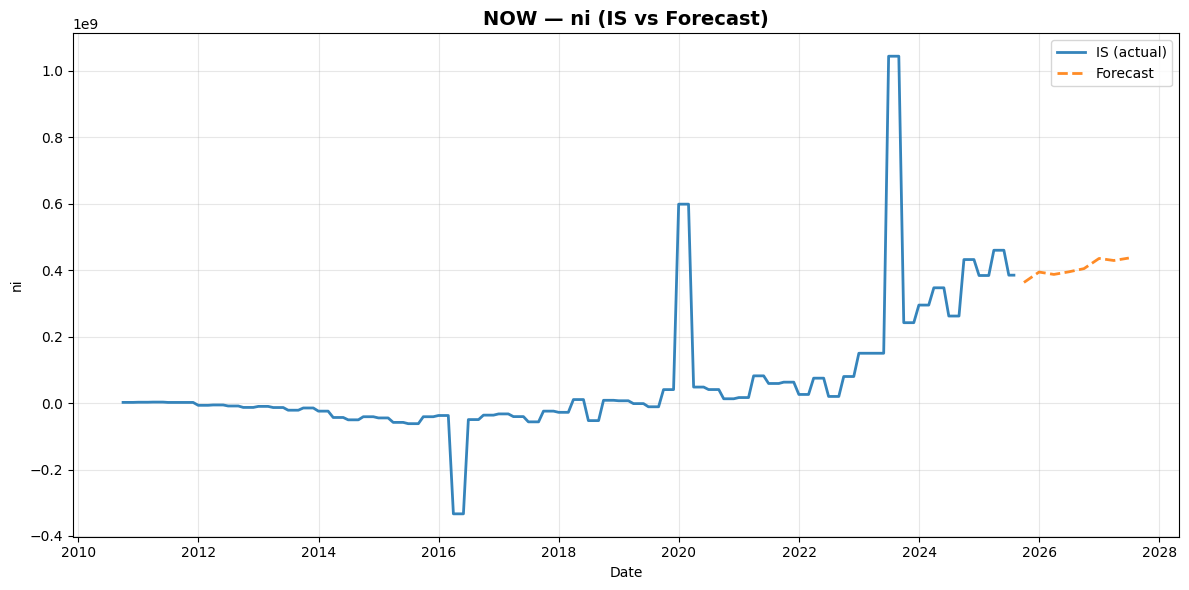

In [75]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sqlalchemy import create_engine, text

# =========================================
# 0) 사용자 입력
# =========================================
# └ 이전 스크립트에서 쓰던 접속 문자열을 그대로 재활용하거나,
#   아래 connection_string을 다시 지정하세요.
from typing import Optional

db_info = {
    "user": "stox7412",
    "password": "Apt106503!~",
    "host": "hystox74.synology.me",
    "port": "3307",
    "database": "investar",
}
connection_string = (
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
    f"@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

table_name = "us_financial_forecasts"   # 당신이 생성한 테이블명
target_ticker = "NOW"                   # 조회할 티커
value_col = "ni"                         # is_df에서 사용할 값 컬럼명 (= us_financial_forecasts.value_type)

# =========================================
# 1) 유틸 함수: 예측(저장) 데이터 로드
# =========================================

def load_forecast_timeseries(
    engine,
    table_name: str,
    ticker: str,
    value_type: str,
    created_date: Optional[str] = None,   # Python 3.9 호환
    use_latest_if_none: bool = True,
) -> pd.DataFrame:
    """
    us_financial_forecasts 테이블에서 특정 (ticker, value_type)의 시계열을 로드하여
    ['date','forecast_value','lower_ci','upper_ci','created_date'] 컬럼으로 반환.
    created_date를 지정하지 않으면 최신 created_date 스냅샷을 자동 선택(옵션).
    """
    with engine.connect() as conn:
        if created_date is None and use_latest_if_none:
            q_latest = text(f"""
                SELECT MAX(created_date) AS latest_created
                FROM {table_name}
                WHERE ticker = :ticker AND value_type = :value_type
            """)
            latest = conn.execute(q_latest, {"ticker": ticker, "value_type": value_type}).scalar()
            if latest is None:
                return pd.DataFrame(columns=["date","forecast_value","lower_ci","upper_ci","created_date"])
            created_date = latest

        q = text(f"""
            SELECT
                forecast_date AS date,
                forecast_value,
                lower_ci,
                upper_ci,
                created_date
            FROM {table_name}
            WHERE ticker = :ticker
              AND value_type = :value_type
              AND (:created_date IS NULL OR created_date = :created_date)
            ORDER BY forecast_date
        """)
        df = pd.read_sql(q, conn, params={
            "ticker": ticker,
            "value_type": value_type,
            "created_date": created_date
        })

    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"])
    for c in ["forecast_value","lower_ci","upper_ci"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.sort_values("date").drop_duplicates(subset=["date"]).reset_index(drop=True)
    return df

# =========================================
# 2) is_df 준비 점검 및 필터링
# =========================================
if "is_df" not in globals():
    raise RuntimeError("❌ 'is_df' DataFrame이 메모리에 없습니다. 미리 로드해 주세요.")

need_cols = {"date","ticker", value_col}
missing = need_cols - set(is_df.columns)
if missing:
    raise RuntimeError(f"❌ is_df에 필요한 컬럼 누락: {missing}")

is_part = (is_df.loc[is_df["ticker"] == target_ticker, ["date", value_col]]
                .copy())
if is_part.empty:
    raise RuntimeError(f"❌ is_df에서 ticker='{target_ticker}' 데이터가 비었습니다.")

is_part["date"] = pd.to_datetime(is_part["date"])
is_part[value_col] = pd.to_numeric(is_part[value_col], errors="coerce")
is_part = (is_part.sort_values("date")
                  .drop_duplicates(subset=["date"])
                  .reset_index(drop=True))
is_part.rename(columns={value_col: "is_value"}, inplace=True)

# =========================================
# 3) DB 로드 + 결합
# =========================================
engine = create_engine(connection_string, pool_pre_ping=True)

fc_df = load_forecast_timeseries(
    engine=engine,
    table_name=table_name,
    ticker=target_ticker,
    value_type=value_col,        # 저장 시 value_type에 ni 등으로 저장했음
    created_date=None,           # 특정 스냅샷을 보고 싶으면 'YYYY-MM-DD HH:MM:SS' 로 지정
    use_latest_if_none=True      # None이면 최신 created_date를 자동 선택
)

engine.dispose()

# 결합 키는 date
merged = (pd.merge(is_part, fc_df, on="date", how="outer")
            .sort_values("date")
            .reset_index(drop=True))

# 양쪽 모두 NaN이면 제거
merged = merged[~(merged["is_value"].isna() & merged["forecast_value"].isna())].copy()

print(f"🔗 결합 완료: {len(merged)}행")
print(merged.head())

# =========================================
# 4) 시각화
# =========================================
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title(f"{target_ticker} — {value_col} (IS vs Forecast)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel(value_col)

# IS 실측 시계열
is_series = merged[["date","is_value"]].dropna()
if not is_series.empty and np.isfinite(is_series["is_value"]).any():
    ax.plot(is_series["date"], is_series["is_value"], "-", linewidth=2, alpha=0.9, label="IS (actual)")

# Forecast 시계열
fc_series = merged[["date","forecast_value"]].dropna()
if not fc_series.empty and np.isfinite(fc_series["forecast_value"]).any():
    ax.plot(fc_series["date"], fc_series["forecast_value"], "--", linewidth=2, alpha=0.9, label="Forecast")

# 신뢰구간 음영 (있으면)
if {"lower_ci","upper_ci"}.issubset(merged.columns):
    ci = merged.dropna(subset=["lower_ci","upper_ci"])
    if not ci.empty and ci["lower_ci"].lt(ci["upper_ci"]).any():
        ax.fill_between(ci["date"], ci["lower_ci"], ci["upper_ci"], alpha=0.15, label="Forecast CI")

ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================
# 5) 결과 DataFrame (필요 시 추가 분석)
# =========================================
# merged에는 다음 열이 포함됩니다:
# ['date', 'is_value', 'forecast_value', 'lower_ci', 'upper_ci', 'created_date']


In [76]:
merged.tail(12)

,date,is_value,forecast_value,lower_ci,upper_ci,created_date
175,2025-04-30,460000000.0,NaN,NaN,NaN,NaT
176,2025-05-31,460000000.0,NaN,NaN,NaN,NaT
177,2025-06-30,385000000.0,NaN,NaN,NaN,NaT
178,2025-07-31,385000000.0,NaN,NaN,NaN,NaT
179,2025-09-30,NaN,3.631567e+08,NaN,NaN,2025-08-20 15:31:10
180,2025-12-31,NaN,3.944073e+08,NaN,NaN,2025-08-20 15:31:10
181,2026-03-31,NaN,3.872455e+08,NaN,NaN,2025-08-20 15:31:10
182,2026-06-30,NaN,3.950519e+08,NaN,NaN,2025-08-20 15:31:10
183,2026-09-30,NaN,4.046815e+08,NaN,NaN,2025-08-20 15:31:10
184,2026-12-31,NaN,4.353623e+08,NaN,NaN,2025-08-20 15:31:10


In [63]:
# 데이터베이스 연결 설정 (필요에 따라 수정)
db_type = 'sqlite'  # 'sqlite', 'mysql', 'postgresql' 중 선택
db_file = '../us_financial_forecasts'  # SQLite의 경우 파일 경로

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}



# ==============================
# 0) 사용자 설정
# ==============================
db_type = 'sqlite'   # 'sqlite' | 'mysql' | 'postgresql'
db_file = '../us_financial_forecasts'  # sqlite 파일명/경로
db_host = ''
db_port = '3307'
db_name = 'investar'
db_user = 's'
db_password = 'Apt106503!~'

# ✅ 여기를 실제로 사용할 ticker와 is_df의 값 컬럼명으로 바꾸세요
target_ticker = 'AAPL'          # 예: 'AAPL'
value_col = 'value'             # 예: is_df에 있는 값 컬럼명 (예: 'value', 'close', 'metric' 등)

# ✅ 실제 테이블/컬럼명으로 수정하세요
query = """
SELECT
    date_column AS date,
    value_column AS value
FROM your_table_name
WHERE date_column >= '2024-01-01'
ORDER BY date_column
"""

# ==============================
# 1) DB에서 데이터 로드 (date, value)
# ==============================
try:
    if db_type == 'sqlite':
        conn = sqlite3.connect(db_file)
        db_df = pd.read_sql_query(query, conn)
        conn.close()
    elif db_type == 'mysql':
        import mysql.connector
        conn = mysql.connector.connect(
            host=db_host, port=db_port, database=db_name,
            user=db_user, password=db_password
        )
        db_df = pd.read_sql_query(query, conn)
        conn.close()
    elif db_type == 'postgresql':
        import psycopg2
        conn = psycopg2.connect(
            host=db_host, port=db_port, database=db_name,
            user=db_user, password=db_password
        )
        db_df = pd.read_sql_query(query, conn)
        conn.close()
    else:
        raise ValueError("db_type은 'sqlite', 'mysql', 'postgresql' 중 하나여야 합니다.")

    print(f"✅ DB 데이터 로드 성공: {len(db_df)}행")
except Exception as e:
    raise RuntimeError(f"⚠️ DB 연결/쿼리 실패: {e}")

# 정리
db_df['date'] = pd.to_datetime(db_df['date'])
db_df = db_df.sort_values('date').reset_index(drop=True)
db_df = db_df[['date', 'value']]

# ==============================
# 2) is_df에서 target_ticker 데이터 준비
#    (is_df는 기존에 메모리에 있다고 가정)
# ==============================
# 안전 점검
if 'is_df' not in globals():
    raise RuntimeError("❌ 'is_df'가 메모리에 없습니다. is_df(DataFrame)를 미리 준비해 주세요.")

required_cols = {'date', 'ticker', value_col}
missing = required_cols - set(is_df.columns)
if missing:
    raise RuntimeError(f"❌ is_df에 필요한 컬럼이 없습니다: {missing}")

# 필터링 및 정리
is_sub = (
    is_df.loc[is_df['ticker'] == target_ticker, ['date', value_col]]
          .copy()
)
if is_sub.empty:
    raise RuntimeError(f"❌ is_df에서 ticker='{target_ticker}' 데이터가 비어 있습니다.")

is_sub['date'] = pd.to_datetime(is_sub['date'])
is_sub = is_sub.sort_values('date').reset_index(drop=True)
is_sub.rename(columns={value_col: 'is_value'}, inplace=True)

# ==============================
# 3) DB vs IS 결합 (date 기준 outer join)
# ==============================
merged = pd.merge(db_df, is_sub, on='date', how='outer').sort_values('date').reset_index(drop=True)

# 둘 다 NaN인 행은 제거 (시각화/통계 안정화)
merged = merged[~(merged['value'].isna() & merged['is_value'].isna())].copy()

print(f"🔗 결합 완료: {len(merged)}행")
print(merged.head())

# ==============================
# 4) 시각화 (line chart만)
# ==============================
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title(f"{target_ticker} — '{value_col}' (DB vs IS)", fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel(value_col)

# DB 시계열
db_series = merged[['date', 'value']].dropna()
if not db_series.empty and np.isfinite(db_series['value']).any():
    ax.plot(db_series['date'], db_series['value'], '-', label='DB (value)', linewidth=2, alpha=0.9)

# IS 시계열
is_series = merged[['date', 'is_value']].dropna()
if not is_series.empty and np.isfinite(is_series['is_value']).any():
    ax.plot(is_series['date'], is_series['is_value'], '--', label=f"IS ({value_col})", linewidth=2, alpha=0.9)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

⚠️ DB 연결/쿼리 실패: Execution failed on sql '
SELECT
    report_date  AS date,
    ni AS value
FROM us_financial_forecasts
WHERE report_date >= '2024-01-01'
ORDER BY report_date
': no such table: us_financial_forecasts
👉 SQLite 파일 내 테이블/컬럼 점검 결과:
🔎 SQLite Tables: []


DatabaseError: Execution failed on sql '
SELECT
    report_date  AS date,
    ni AS value
FROM us_financial_forecasts
WHERE report_date >= '2024-01-01'
ORDER BY report_date
': no such table: us_financial_forecasts

In [52]:
is_df

,date,report_date,ticker,period,sale,cogs,gp,xrd,xsga,idit,...,pir,txt,ni,nir,eps,epsdi,shrout,shroutdi,date_month,type
212,2021-09-30,2021-09-30,HAFN,Q3,1.897319e+08,195728362.0,-5996414.0,0.0,8940563.0,758811.0,...,-0.098143,1445546.0,-20758204.0,-0.109408,-0.0572,-0.0572,363157622.0,363157622.0,2021-09,historical
213,2021-10-31,2021-09-30,HAFN,Q3,1.897319e+08,195728362.0,-5996414.0,0.0,8940563.0,758811.0,...,-0.098143,1445546.0,-20758204.0,-0.109408,-0.0572,-0.0572,363157622.0,363157622.0,2021-09,historical
214,2021-11-30,2021-09-30,HAFN,Q3,1.897319e+08,195728362.0,-5996414.0,0.0,8940563.0,758811.0,...,-0.098143,1445546.0,-20758204.0,-0.109408,-0.0572,-0.0572,363157622.0,363157622.0,2021-09,historical
215,2021-12-31,2021-12-31,HAFN,Q4,2.416595e+08,229874292.0,11785255.0,0.0,10197010.0,958287.0,...,-0.024136,1793945.0,-7810686.0,-0.032321,-0.0215,-0.0215,363157622.0,363157622.0,2021-12,historical
216,2022-01-31,2021-12-31,HAFN,Q4,2.416595e+08,229874292.0,11785255.0,0.0,10197010.0,958287.0,...,-0.024136,1793945.0,-7810686.0,-0.032321,-0.0215,-0.0215,363157622.0,363157622.0,2021-12,historical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77178,2025-03-31,2025-03-28,FTV,Q1,1.474200e+09,593300000.0,880900000.0,105100000.0,542200000.0,0.0,...,0.136616,29500000.0,171900000.0,0.116606,0.5000,0.5000,341100000.0,344600000.0,2025-03,historical
77179,2025-04-30,2025-03-28,FTV,Q1,1.474200e+09,593300000.0,880900000.0,105100000.0,542200000.0,0.0,...,0.136616,29500000.0,171900000.0,0.116606,0.5000,0.5000,341100000.0,344600000.0,2025-03,historical
77180,2025-05-31,2025-03-28,FTV,Q1,1.474200e+09,593300000.0,880900000.0,105100000.0,542200000.0,0.0,...,0.136616,29500000.0,171900000.0,0.116606,0.5000,0.5000,341100000.0,344600000.0,2025-03,historical
77181,2025-06-30,2025-06-27,FTV,Q2,1.518800e+09,623100000.0,895700000.0,109200000.0,564300000.0,0.0,...,0.126416,25400000.0,166600000.0,0.109692,0.4900,0.4900,339600000.0,341700000.0,2025-06,historical
